# Notebook 2 — Training and Evaluation

Trains a damage classifier on the patches prepared by notebook 1 and
evaluates it region by region against the PWTT baseline. **No Earth Engine
needed** — everything is read from Drive.

One experiment = one `CONFIG` dictionary. Changing the model, the features,
the split or the augmentations should never require edits below Section 1.
Every run writes its config, checkpoints, metrics and figures to
`experiments/{experiment_name}/`.

## The pipeline this notebook builds

```
        patches (pre + post, memory mapped)
                    |
                   CNN                     <- stage 1, per patch
                    |
      scores at t-24, t-12, t, t+12, t+24  <- same CNN, offset post imagery
                    |
                  XGBoost                  <- stage 2, per building
                    |
     spatial features + temporal features
```

The CNN sees one patch at a time and knows nothing about where a building
sits or what it looked like a fortnight earlier. Both of those carry real
information, and both are the second stage's job:

* **Spatial** — damage is clustered. A 0.6 in a block of 0.9s means something
  different from a 0.6 in a block of 0.1s.
* **Temporal** — damage persists, speckle flickers. The same CNN scored on
  post imagery from ±12 and ±24 days gives each building a short series, and
  the shape of that series separates a real collapse from a noisy pixel.

## What this notebook compares

The validation table compares every training run and variant:

| variant | what it adds |
|---|---|
| `cnn` | stage 1 alone |
| `cnn+fixed_neighbor_rule` | fixed weighted-neighbour equation — a non-learned control |
| `xgb_spatial` | learned second stage, spatial features only |
| `xgb_spatial_temporal` | learned second stage, spatial + temporal |

The hand-set and Optuna-tuned runs are compared on validation only. The
highest mean validation PR-AUC locks one run, one variant, and one
validation-fitted threshold. Only that frozen pipeline is then evaluated
once on the sealed test split.

`cnn+fixed_neighbor_rule` is not a second model. It is a fixed equation used as a control: if the learned stage only matches
"average with your neighbours", the machinery bought nothing.

## Where each decision is made

| decision | fitted on | never sees |
|---|---|---|
| CNN weights | train band | val, stack, test |
| CNN hyperparameters (Optuna) | val PR-AUC | test |
| second-stage model | stack band | test |
| second-stage early stopping | val band | test |
| final run and variant | mean val PR-AUC | test |
| every decision threshold | val band | test |

No test-optimal threshold or alternative candidate is evaluated on test.
Test metrics use the threshold frozen on validation.

## 1. Setup and configuration

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q optuna xgboost

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 21.1 MB/s eta 0:00:00


In [2]:
import sys
BASE = "/content/drive/MyDrive/War-Damage-Detection"
sys.path.append(BASE)

import os
import json
import pickle
import copy
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import (precision_recall_fscore_support, average_precision_score,
                             roc_auc_score, precision_recall_curve)

from pipeline import (PREP, CITY_REGISTRY, PWTT_THRESHOLD, PatchSource,
                      EXPERIMENTS_DIR,
                      load_city, post_arrays, usable_mask, city_source,
                      wanted_channels, label_matrix, propagate_labels,
                      parse_split_entry, parse_entry, expand_split, strip_dates,
                      band_mask, split_assignment,
                      temporal_offsets, temporal_window_days, shift_date,
                      spatial_smooth, neighbour_features, temporal_features,
                      MODEL_REGISTRY, build_model, predict_probs,
                      best_f1_threshold, experiment_dirs,
                      city_role, held_out_cities, holdout_split_entries,
                      check_split_holdout, load_run, list_saved_runs,
                      list_experiments)

# ---------------------------------------------------------------------------
# EVALUATE_ONLY: reload a finished experiment instead of fitting anything.
#
# False  normal path - train (or resume), run HPO, fit the stackers, select.
# True   load the CNNs and stackers this experiment already saved and go
#        straight to scoring. Nothing is fitted, so nothing can change: the
#        frozen final_selection.json still decides the pipeline and the
#        threshold. Use it to re-run validation and the final test - including
#        the holdout cities - after adding a city or restarting Colab.
#
# In this mode mu/sd come from the CHECKPOINT rather than being recomputed,
# which is both much faster and the only correct choice: they are part of the
# fitted model.
# ---------------------------------------------------------------------------
EVALUATE_ONLY = False

if not os.path.exists(EXPERIMENTS_DIR):
    print("no experiments folder yet")
else:
    _known = list_experiments()
    if len(_known):
        print("experiments on Drive:")
        print(_known.to_string(index=False))
        print()

CONFIG = {
    "experiment_name": "exp001_base_cnn_sar_temporal",
    "seed": 0,

    # which channels the model sees (must be a subset of what notebook 1
    # exported, see PREP["sensors"] in pipeline.py)
    "features": {
        "sentinel1": True,
        "sentinel2": False,
        "pre_event": True,
        "post_event": True,
    },

    # one of the keys in MODEL_REGISTRY: "small_cnn" or "siamese".
    # New models are added in pipeline.py with @register_model.
    "model": "base_cnn",

    # Architecture hyperparameters. Optuna searches these; these values are
    # the hand-set baseline it is compared against.
    # width is the first block's filter count, and every later block doubles it.
    # depth is the number of conv blocks. Each block is conv 3×3 -> BatchNorm -> ReLU -> MaxPool(2), so every block halves the spatial size.
    "model_params": {}, #"width": 32, "depth": 2, "dropout": 0.3},

    # A split entry is "City", or "City:lo-hi" for a latitude quantile band,
    # optionally followed by "@date". "@*" expands to every registered
    # assessment date of that city.
    #
    # Bands make train, validation and test spatially disjoint: a random split
    # would leak through spatial autocorrelation, because a 32 px patch is
    # 320 m across and neighbouring buildings share pixels.
    #
    # val and stack use "@*" ON PURPOSE. Prevalence in this band climbs from
    # 54 to 65 percent across the three assessments, so a threshold fitted at
    # one date is calibrated to that date and systematically wrong for the
    # others. Fitting across dates gives a date-agnostic threshold, which is
    # what you need if the model is ever pointed at a new date. The cost is
    # mild pseudo-replication: the same building appears three times, so the
    # effective sample is smaller than the row count.
    #
    # Never hold out a DATE instead of a band: almost every building damaged
    # in May is still damaged in September, so training on one date and
    # testing on another would overlap almost completely.
    "split": {
        "train": ["Gaza:0.55-1.00@*"],              # explicitly use all registered dates
        # the second stage needs CNN scores the CNN has NOT seen, so it gets a
        # band of its own rather than reusing train or val
        "stack": ["Gaza:0.42-0.55@*"],
        "val":   ["Gaza:0.33-0.42@*"],
        "test":  ["Gaza:0.00-0.33@20240503",
                  "Gaza:0.00-0.33@20240706",
                  "Gaza:0.00-0.33@20240906"],

        # Whole cities never touched by any band above. "test" measures
        # unseen GROUND in the city the model knows; this measures a whole
        # unseen CITY - different building stock, incidence angle, conflict
        # and season. They are reported separately in Section 10 because a
        # single averaged number would hide exactly the gap worth seeing.
        #
        # Defaults to every role="holdout" city in CITY_REGISTRY, so
        # registering one there is enough. Replace with an explicit list to
        # evaluate only some of them.
        "holdout": holdout_split_entries(),
    },

    # If True, enforce cumulative labels: once damaged, remain damaged at
    # subsequent assessments. The @date / @* syntax controls which dates
    # enter training; this flag only controls label correction.
    "label_temporal": False,

    # Fixed-weight smoothing of the CNN's scores, used as the control variant.
    # Not applied to the CNN's own scores anywhere else: the base CNN should
    # judge each patch on its own and leave the neighbourhood to stage two.
    "spatial_smoothing": {"k": 8, "weight": 0.3},

    # Second stage over the CNN's scores.
    "stacking": {
        "enabled": True,
        "ks": [8, 32],            # neighbourhood sizes, in buildings
        "n_estimators": 600,
        "max_depth": 4,
        "learning_rate": 0.05,
        "early_stopping_rounds": 40,
    },

    # Temporal features for the second stage. offsets None = PREP["temporal"].
    # Set enabled False to skip scoring the offset dates entirely.
    "temporal_stacking": {
        "enabled": True,
        "offsets": None,
    },

    # Hyperparameter search over the CNN. Trials are short and run on a
    # subsample; the winner is then retrained with the full budget.
    "hpo": {
        "enabled": True,
        "n_trials": 10, # 20,  # target total; may be increased when resuming
        "max_epochs": 25,          # per trial, vs max_epochs below for the final fit
        "train_subsample": 0.5,    # fraction of training rows per trial
        "timeout_minutes": None, #90,     # None for no limit
        "patience": 6,
    },

    # training
    "batch_size": 128,
    "learning_rate":  1e-3,
    "weight_decay": 1e-4,
    "max_epochs": 120,
    "early_stopping_patience": 10,
    "num_workers": 2,
    "predict_batch": 1024,
}

# Console progress only; changing this does not define a new experiment.
HPO_LOG_EVERY = 5


def validate_config(cfg):
    """Fail early with a readable message instead of a confusing crash later."""
    f = cfg["features"]
    if not (f["sentinel1"] or f["sentinel2"]):
        raise ValueError("enable at least one of sentinel1 / sentinel2")
    if not (f["pre_event"] or f["post_event"]):
        raise ValueError("enable at least one of pre_event / post_event")
    if cfg["model"] not in MODEL_REGISTRY:
        raise ValueError(f"unknown model, choose one of {list(MODEL_REGISTRY)}")
    if cfg["model"] == "siamese" and not (f["pre_event"] and f["post_event"]):
        raise ValueError("siamese compares pre and post, enable both")
    if cfg["temporal_stacking"]["enabled"] and not f["post_event"]:
        raise ValueError("temporal features vary the POST window, so post_event "
                         "must be on for them to mean anything")
    if cfg["temporal_stacking"]["enabled"] and not cfg["stacking"]["enabled"]:
        raise ValueError("temporal features are consumed by the second stage; "
                         "enable stacking or disable temporal_stacking")


def validate_split(cfg):
    """No holdout city may leak into a part the model is developed on."""
    leaks = check_split_holdout(cfg["split"])
    if leaks:
        for part, entry, city in leaks:
            print(f"   {part}: {entry}  (city {city} is role=holdout)")
        raise RuntimeError(
            "holdout cities appear in a development split part (listed "
            "above). Move them to split['holdout'], or change the city's "
            "role in CITY_REGISTRY if it really is meant to be developed on.")


validate_config(CONFIG)
validate_split(CONFIG)
np.random.seed(CONFIG["seed"])
torch.manual_seed(CONFIG["seed"])
device = "cuda" if torch.cuda.is_available() else "cpu"

SPLIT = expand_split(CONFIG["split"])
OFFSETS = (CONFIG["temporal_stacking"]["offsets"] or temporal_offsets()
           if CONFIG["temporal_stacking"]["enabled"] else [0])
if 0 not in OFFSETS:
    OFFSETS = sorted(set(OFFSETS) | {0})

def experiment_identity(cfg):
    """The config that defines the FITTED pipeline.

    Two things are excluded because changing them cannot change any model,
    any selection or any threshold:

    hpo.n_trials / hpo.timeout_minutes
        resumable budgets - more trials continue the same study.

    split["holdout"]
        whole cities that are only ever scored, never fitted on. Registering
        a new holdout city must not invalidate a finished experiment, and it
        also means experiments created before the holdout part existed still
        compare equal.
    """
    identity = copy.deepcopy(cfg)
    # .get(): this also runs against configs embedded in older checkpoints,
    # which may predate a key entirely.
    identity.get("hpo", {}).pop("n_trials", None)
    identity.get("hpo", {}).pop("timeout_minutes", None)
    identity.get("split", {}).pop("holdout", None)
    return identity


def atomic_config_dump(cfg, path):
    tmp = path + ".tmp"
    with open(tmp, "w") as fh:
        json.dump(cfg, fh, indent=2)
    os.replace(tmp, path)


EXP_ROOT, OUT = experiment_dirs(CONFIG["experiment_name"])
config_path = os.path.join(EXP_ROOT, "config.json")

if os.path.exists(config_path):
    with open(config_path) as fh:
        previous_config = json.load(fh)

    if experiment_identity(previous_config) != experiment_identity(CONFIG):
        raise RuntimeError(
            f"{EXP_ROOT} already contains a different scientific configuration. "
            "Only hpo.n_trials and hpo.timeout_minutes may change in place; "
            "otherwise choose a new experiment_name."
        )

    old_trials = int(previous_config["hpo"]["n_trials"])
    new_trials = int(CONFIG["hpo"]["n_trials"])
    if new_trials < old_trials:
        raise RuntimeError(
            f"Cannot reduce hpo.n_trials from {old_trials} to {new_trials} "
            "inside an existing experiment."
        )

    budget_changed = (
        old_trials != new_trials or
        previous_config["hpo"].get("timeout_minutes")
        != CONFIG["hpo"].get("timeout_minutes"))
    holdout_changed = (previous_config.get("split", {}).get("holdout")
                       != CONFIG["split"].get("holdout"))

    if previous_config != CONFIG:
        atomic_config_dump(CONFIG, config_path)
        if budget_changed:
            print(
                f"Updated the resumable HPO budget: n_trials {old_trials} -> "
                f"{new_trials}. Existing completed/pruned trials will be reused."
            )
        if holdout_changed:
            print(
                "Updated the holdout city list. These are evaluation targets "
                "only, so every fitted model and the frozen selection are "
                "unaffected; Section 11 will score the cities it has not "
                "already sealed."
            )
    else:
        print(
            "Existing compatible configuration found. Completed models and HPO "
            "trials will be reused; unfinished CNN training will resume."
        )
else:
    atomic_config_dump(CONFIG, config_path)
    print("Created new experiment configuration.")

CHANNEL_NAMES = wanted_channels(CONFIG["features"])
print(f"experiment folder: {EXP_ROOT}")
print(f"device: {device}")
print(f"active channels ({len(CHANNEL_NAMES)}): {CHANNEL_NAMES}")
print(f"temporal offsets scored: {OFFSETS}")
print(f"mode: {'EVALUATE_ONLY - nothing will be fitted' if EVALUATE_ONLY else 'train / fit'}")
print("\nsplit after expanding @*:")
for part in ["train", "stack", "val", "test"]:
    print(f"  {part:8s} {SPLIT.get(part, [])}")
print(f"  {'holdout':8s} {SPLIT.get('holdout', [])}")
print(f"\nholdout cities registered: {held_out_cities()}")
print("test = Gaza's own southern band (unseen ground, known city); "
      "holdout = whole unseen cities")

experiments on Drive:
                  experiment     runs  stackers              selection  tested         modified
exp001_base_cnn_sar_temporal baseline      True baseline / xgb_spatial    True 2026-08-24 21:24

Existing compatible configuration found. Completed models and HPO trials will be reused; unfinished CNN training will resume.
experiment folder: /content/drive/MyDrive/War-Damage-Detection/experiments/exp001_base_cnn_sar_temporal
device: cuda
active channels (4): ['s1_pre_VV', 's1_pre_VH', 's1_post_VV', 's1_post_VH']
temporal offsets scored: [-24, -12, 0, 12, 24]
mode: train / fit

split after expanding @*:
  train    ['Gaza:0.55-1.00@20240503', 'Gaza:0.55-1.00@20240706', 'Gaza:0.55-1.00@20240906']
  stack    ['Gaza:0.42-0.55@20240503', 'Gaza:0.42-0.55@20240706', 'Gaza:0.42-0.55@20240906']
  val      ['Gaza:0.33-0.42@20240503', 'Gaza:0.33-0.42@20240706', 'Gaza:0.33-0.42@20240906']
  test     ['Gaza:0.00-0.33@20240503', 'Gaza:0.00-0.33@20240706', 'Gaza:0.00-0.33@20240906']
  

## 2. Build the development sets

Each split entry becomes one **part**: one latitude band of one city at one
assessment date. A part stores only row indices into that city's canonical
building table — never pixels — so the patches for any offset can be
materialised lazily whenever they are needed.

Rows are filtered to buildings whose patch is usable at that date (complete in
both the pre and the post array). At a *temporal offset* a few more buildings
may drop out; those become NaN scores rather than dropped rows, and XGBoost
handles the missing value natively by learning a default direction at each
split. Imputing a score that was never measured would be worse.

Only train, stack, and validation parts are constructed here. The test parts
remain sealed until the final run and variant have been written to a frozen
selection manifest.

In [3]:
CITY_CACHE = {}


def city_data(name):
    if name not in CITY_CACHE:
        CITY_CACHE[name] = load_city(name)
    return CITY_CACHE[name]


def labels_for(d, date, propagate):
    """The label column for one date, optionally propagated forward in time."""
    dates = CITY_REGISTRY[d["city"]]["label_dates"]
    if not propagate or len(dates) < 2:
        return d["table"][f"class_{date}"].to_numpy(int)
    Y = propagate_labels(label_matrix(d["table"], dates))
    return Y[:, dates.index(date)]


def make_part(entry, propagate=False):
    """One band of one city at one date, as row indices into its table."""
    cty, lo, hi, date = parse_entry(entry)
    d = city_data(cty)
    date = date or CITY_REGISTRY[cty]["label_dates"][-1]
    rows = np.where(band_mask(d["lat"], lo, hi) & usable_mask(d, date))[0]
    y = labels_for(d, date, propagate)[rows]
    name = entry if "@" in entry else f"{entry}@{date}"
    return {"name": name, "city": cty, "date": date, "rows": rows, "y": y,
            "xy": d["xy"][rows], "lon": d["lon"][rows], "lat": d["lat"][rows],
            "table": d["table"].iloc[rows]}


def build_parts(entries, propagate=False):
    parts = []
    for entry in entries:
        cty, lo, hi, date = parse_entry(entry)
        if date is None and propagate and len(CITY_REGISTRY[cty]["label_dates"]) > 1:
            # no date pinned and temporal labels on: one part per date
            for dt in CITY_REGISTRY[cty]["label_dates"]:
                parts.append(make_part(f"{entry}@{dt}", propagate=True))
        else:
            parts.append(make_part(entry, propagate=propagate))
    return parts


def part_source(p, offset=0):
    """(PatchSource, positions) for a part at one temporal offset.

    positions says where in the part each returned row sits, so a score
    vector can be scattered back into a full-length array. At offset 0 every
    row is present by construction; at other offsets a few may be missing.
    """
    d = city_data(p["city"])
    if offset == 0:
        date, window = p["date"], None
    else:
        date, window = shift_date(p["date"], offset), temporal_window_days()
    src, rows = city_source(d, date, CONFIG["features"], rows=p["rows"],
                            window_days=window)
    return src, np.searchsorted(p["rows"], rows)


train_parts = build_parts(SPLIT["train"], propagate=CONFIG["label_temporal"])
val_parts = build_parts(SPLIT["val"])
stack_parts = build_parts(SPLIT["stack"]) if CONFIG["stacking"]["enabled"] else []

# PatchSource joins the pre and post arrays channel-wise, keeps one latitude
# band, and glues the dates end to end - none of which reads a pixel. The
# patches stay memory-mapped on disk, so only the batch in use is ever in RAM.
X_tr = PatchSource.concat([part_source(p)[0] for p in train_parts])
y_tr = np.concatenate([p["y"] for p in train_parts])
X_va = PatchSource.concat([part_source(p)[0] for p in val_parts])
y_va = np.concatenate([p["y"] for p in val_parts])

# Normalization statistics come from the training data and nowhere else.
#
# In EVALUATE_ONLY mode they are read back from the checkpoint instead of
# recomputed. That is not just a speed-up: mu/sd are part of the fitted
# model, so a holdout city has to be normalised by the SAME numbers the CNN
# was trained under. Recomputing them - on any data - would feed the network
# inputs on a different scale from the ones it learned.
SAVED_RUN_TAGS = list_saved_runs(OUT["models"])

if EVALUATE_ONLY:
    if not SAVED_RUN_TAGS:
        raise RuntimeError(
            f"EVALUATE_ONLY is on but {OUT['models']} holds no completed run. "
            "Train the experiment first, or set EVALUATE_ONLY = False.")
    _ref = load_run(OUT["models"], SAVED_RUN_TAGS[0], device="cpu")
    mu, sd = _ref["mu"], _ref["sd"]
    if _ref["channel_names"] != CHANNEL_NAMES:
        raise RuntimeError(
            f"checkpoint was trained on channels {_ref['channel_names']} but "
            f"CONFIG asks for {CHANNEL_NAMES}.")
    del _ref
    print(f"channel statistics reused from checkpoint "
          f"'{SAVED_RUN_TAGS[0]}' (no training patches read)")
else:
    # channel_stats streams the file in batches and accumulates in float64.
    t0 = time.time()
    mu, sd = X_tr.channel_stats()
    print(f"channel statistics from {len(X_tr):,} training patches "
          f"({time.time() - t0:.0f}s)")
for n, m, s in zip(CHANNEL_NAMES, mu.ravel(), sd.ravel()):
    print(f"   {n:14s} mean {m:8.3f}  sd {s:6.3f}")

print(f"\ntrain n={len(y_tr):6d}  damaged={y_tr.mean()*100:5.2f} percent")
print(f"val   n={len(y_va):6d}  damaged={y_va.mean()*100:5.2f} percent")
for kind, parts in [("stack", stack_parts)]:
    for p in parts:
        print(f"{kind:5s} {p['name']:28s} n={len(p['y']):6d}  "
              f"damaged={p['y'].mean()*100:5.2f} percent")

# the evaluation bands must share no building with training, at any date
train_ids = set().union(*[set(p["table"]["system:index"]) for p in train_parts])
for p in val_parts + stack_parts:
    overlap = train_ids & set(p["table"]["system:index"])
    if overlap:
        raise RuntimeError(f"{p['name']}: {len(overlap):,} buildings also appear "
                           f"in training. Check the band boundaries.")
print("\nno building appears in both training and development evaluation")

channel statistics from 295,098 training patches (18s)
   s1_pre_VV      mean   -8.140  sd  2.858
   s1_pre_VH      mean  -13.975  sd  3.196
   s1_post_VV     mean   -8.142  sd  3.404
   s1_post_VH     mean  -14.336  sd  4.190

train n=295098  damaged=73.39 percent
val   n= 59019  damaged=76.20 percent
stack Gaza:0.42-0.55@20240503      n= 28417  damaged=36.05 percent
stack Gaza:0.42-0.55@20240706      n= 28417  damaged=37.97 percent
stack Gaza:0.42-0.55@20240906      n= 28417  damaged=43.01 percent

no building appears in both training and development evaluation


In [4]:
# Are the offset patches actually there? Cheap to check now, annoying to
# discover after a two-hour training run.
missing = []
for p in stack_parts + val_parts:
    for off in OFFSETS:
        if off == 0:
            continue
        try:
            src, pos = part_source(p, off)
            frac = len(pos) / max(len(p["y"]), 1)
            if frac < 0.9:
                print(f"   {p['name']} {off:+d}d: only {frac*100:.0f} percent of "
                      f"buildings have a patch, the rest become NaN features")
        except FileNotFoundError as e:
            missing.append((p["name"], off))
if missing:
    print("MISSING offset patches (notebook 1 has not cut them):")
    for name, off in missing[:10]:
        print(f"   {name} {off:+d} days")
    print("Run notebook 1 section 4, or set temporal_stacking.enabled = False.")
else:
    print(f"all {len(OFFSETS) - 1} offsets available for every scored part")

all 4 offsets available for every scored part


### The split, on a map

The bands are **stacked, not interleaved** — that is the whole point. A 32 px
patch is 320 m across, far wider than a building, so neighbouring buildings
share pixels. Under a random split those shared pixels would land on both
sides of the train/test divide and the test score would flatter the model.

The map shows only locations, roles, and counts. Test labels and test
prevalence are deliberately not inspected during development.

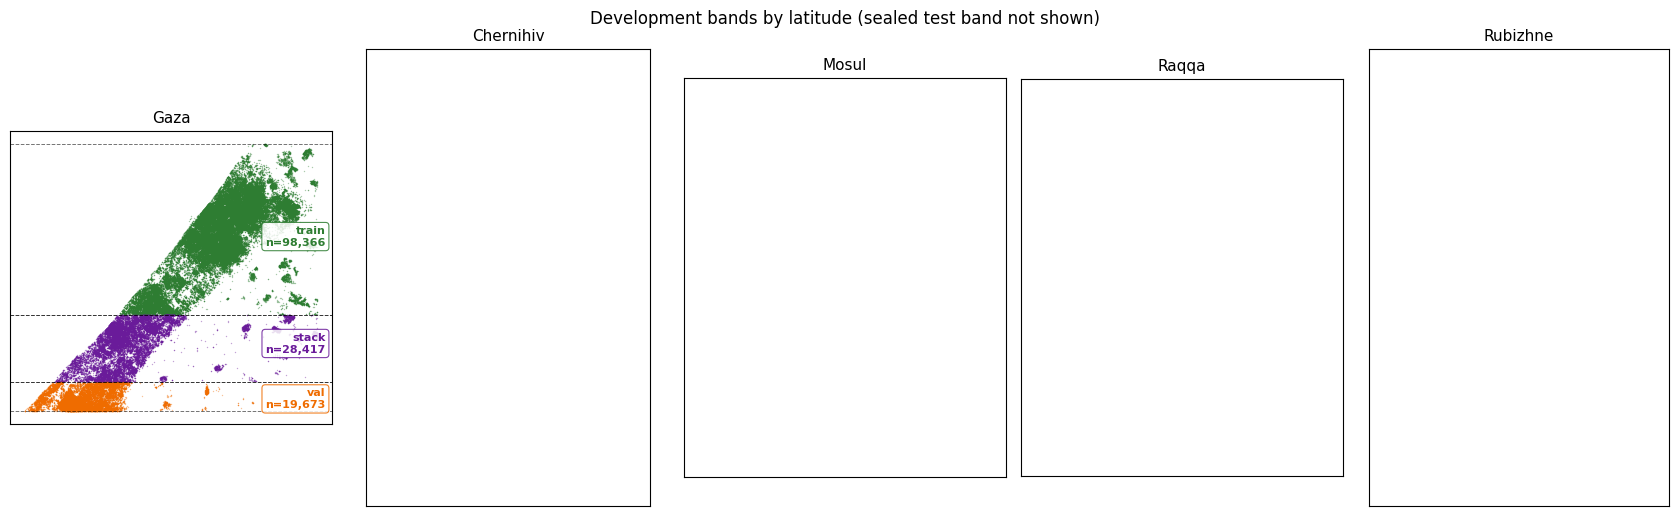

city split  buildings
Gaza train      98366
Gaza stack      28417
Gaza   val      19673


In [5]:
def plot_split_map(split_cfg, path=None):
    """Map development buildings by their train/stack/validation role.

    The map shows WHERE each development split is, so @dates are stripped
    here. Only coordinates are used; test labels remain sealed.
    """
    bands = strip_dates({k: v for k, v in split_cfg.items() if k != "test"})
    cities = []
    for part in bands:
        for entry in bands[part]:
            c = parse_split_entry(entry)[0]
            if c not in cities:
                cities.append(c)

    colors = {"train": "#2E7D32", "stack": "#6A1B9A", "val": "#EF6C00"}

    data = {}
    for c in cities:
        d = city_data(c)
        data[c] = (d["lat"], d["lon"])

    # a degree of longitude is shorter than a degree of latitude away from the
    # equator, so set the aspect by cos(latitude) to get the real shape
    def extent(c):
        lat, lon = data[c]
        k = np.cos(np.radians(lat.mean()))
        return (np.ptp(lon) * k), np.ptp(lat), 1 / k

    panel_w = 3.4
    tallest = max(h / (w or 1) for w, h, _ in map(extent, cities))
    fig, axes = plt.subplots(
        1, len(cities), squeeze=False,
        figsize=(panel_w * len(cities), min(panel_w * tallest + 1.0, 9.0)))

    rows = []
    for ax, c in zip(axes[0], cities):
        lat, lon = data[c]
        role = split_assignment(lat, c, bands)
        for r in ["train", "stack", "val"]:
            m = role == r
            if not m.any():
                continue
            ax.scatter(lon[m], lat[m], s=1.0, alpha=0.4, color=colors[r],
                       label=r, linewidths=0)
            rows.append({"city": c, "split": r, "buildings": int(m.sum())})
            ax.text(0.98, lat[m].mean(),
                    f"{r}\nn={m.sum():,}",
                    transform=ax.get_yaxis_transform(), ha="right", va="center",
                    fontsize=8, color=colors[r], fontweight="bold",
                    bbox=dict(boxstyle="round,pad=0.3", fc="white",
                              ec=colors[r], alpha=0.85, lw=0.8))
        for part in bands:
            for entry in bands[part]:
                c_, lo, hi = parse_split_entry(entry)
                if c_ == c and (lo > 0 or hi < 1):
                    for q in (lo, hi):
                        ax.axhline(np.quantile(lat, q), color="black", lw=0.7,
                                   ls="--", alpha=0.55)
        ax.set_title(c, fontsize=11, pad=6)
        ax.set_aspect(extent(c)[2])
        ax.set_xticks([]); ax.set_yticks([])

    fig.suptitle("Development bands by latitude (sealed test band not shown)",
                 fontsize=12)
    fig.tight_layout()
    if path:
        fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()

    summary = pd.DataFrame(rows)
    summary = summary.reset_index(drop=True)
    print(summary.to_string(index=False))
    return summary


split_summary = plot_split_map(SPLIT, os.path.join(OUT["figures"], "split_map.png"))

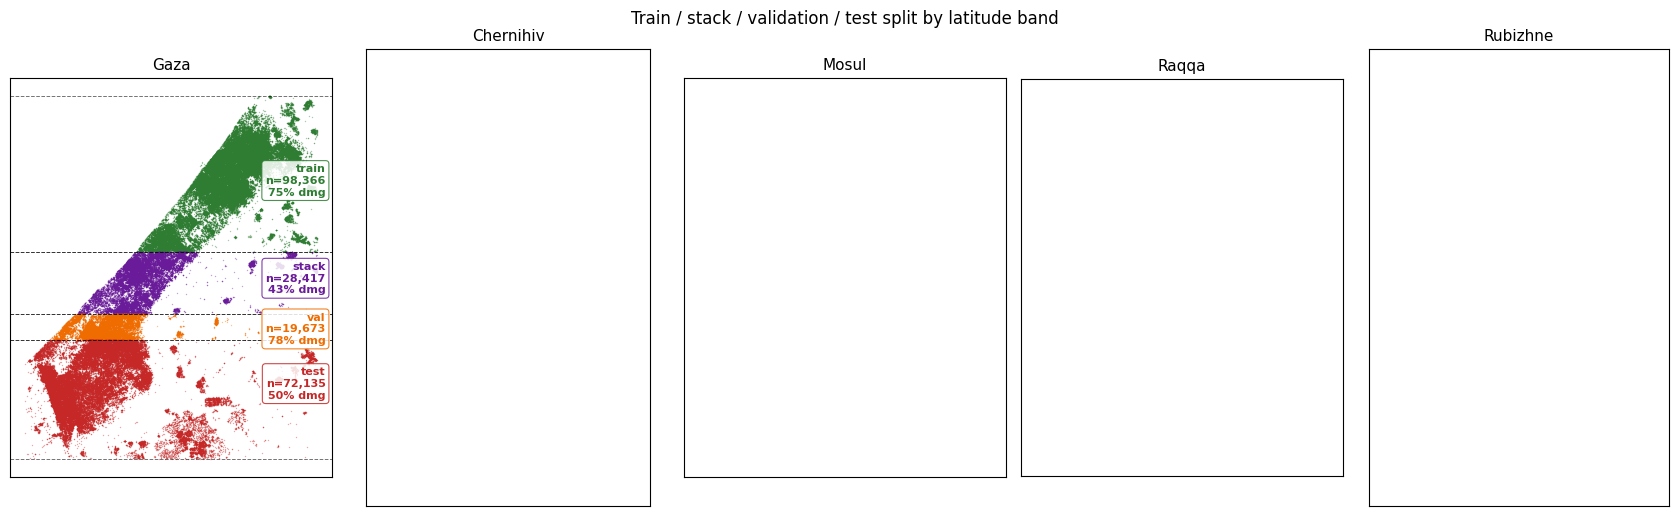

city split  buildings  damaged %
Gaza train      98366      74.52
Gaza stack      28417      43.01
Gaza   val      19673      77.51
Gaza  test      72135      50.19

NOTE: the damaged share varies by 35 percentage points across the bands. Damage is not distributed uniformly from north to south, so a threshold calibrated on validation may transfer differently to test.


In [6]:
def plot_split_map(split_cfg, path=None):
    """Map every building by its train/stack/validation/test role.

    The @date suffixes are stripped because the geographical split does not
    change between assessment dates. Damage frequencies use the latest
    registered label date for each city.
    """
    bands = strip_dates(split_cfg)

    cities = []
    for part in bands:
        for entry in bands[part]:
            c = parse_split_entry(entry)[0]
            if c not in cities:
                cities.append(c)

    colors = {
        "train": "#2E7D32",
        "stack": "#6A1B9A",
        "val": "#EF6C00",
        "test": "#C62828",
        "unused": "#CFCFCF",
    }

    data = {}
    for c in cities:
        d = city_data(c)
        latest_date = CITY_REGISTRY[c]["label_dates"][-1]
        labels = d["table"][f"class_{latest_date}"].to_numpy(int)
        data[c] = (d["lat"], d["lon"], labels)

    # A degree of longitude is shorter than a degree of latitude away from
    # the equator. Adjust the aspect ratio to show the city's real shape.
    def extent(c):
        lat, lon, _ = data[c]
        k = np.cos(np.radians(lat.mean()))
        return (np.ptp(lon) * k), np.ptp(lat), 1 / k

    panel_w = 3.4
    tallest = max(h / (w or 1) for w, h, _ in map(extent, cities))

    fig, axes = plt.subplots(
        1,
        len(cities),
        squeeze=False,
        figsize=(
            panel_w * len(cities),
            min(panel_w * tallest + 1.0, 9.0),
        ),
    )

    rows = []

    for ax, c in zip(axes[0], cities):
        lat, lon, y = data[c]
        role = split_assignment(lat, c, bands)

        for r in ["unused", "train", "stack", "val", "test"]:
            mask = role == r
            if not mask.any():
                continue

            damaged_share = float(y[mask].mean())

            ax.scatter(
                lon[mask],
                lat[mask],
                s=1.0,
                alpha=0.4,
                color=colors[r],
                label=r,
                linewidths=0,
            )

            rows.append(
                {
                    "city": c,
                    "split": r,
                    "buildings": int(mask.sum()),
                    "damaged %": round(damaged_share * 100, 2),
                }
            )

            ax.text(
                0.98,
                lat[mask].mean(),
                f"{r}\n"
                f"n={mask.sum():,}\n"
                f"{damaged_share * 100:.0f}% dmg",
                transform=ax.get_yaxis_transform(),
                ha="right",
                va="center",
                fontsize=8,
                color=colors[r],
                fontweight="bold",
                bbox=dict(
                    boxstyle="round,pad=0.3",
                    fc="white",
                    ec=colors[r],
                    alpha=0.85,
                    lw=0.8,
                ),
            )

        # Draw the latitude-quantile boundaries between the split bands.
        for part in bands:
            for entry in bands[part]:
                city_name, lo, hi = parse_split_entry(entry)

                if city_name == c and (lo > 0 or hi < 1):
                    for q in (lo, hi):
                        ax.axhline(
                            np.quantile(lat, q),
                            color="black",
                            lw=0.7,
                            ls="--",
                            alpha=0.55,
                        )

        ax.set_title(c, fontsize=11, pad=6)
        ax.set_aspect(extent(c)[2])
        ax.set_xticks([])
        ax.set_yticks([])

    fig.suptitle(
        "Train / stack / validation / test split by latitude band",
        fontsize=12,
    )
    fig.tight_layout()

    if path:
        fig.savefig(path, dpi=150, bbox_inches="tight")

    plt.show()

    summary = pd.DataFrame(rows)
    summary = (
        summary[summary["split"] != "unused"]
        .reset_index(drop=True)
    )

    print(summary.to_string(index=False))

    spread = summary["damaged %"].max() - summary["damaged %"].min()
    if spread > 15:
        print(
            f"\nNOTE: the damaged share varies by {spread:.0f} percentage "
            "points across the bands. Damage is not distributed uniformly "
            "from north to south, so a threshold calibrated on validation "
            "may transfer differently to test."
        )

    return summary


split_summary = plot_split_map(
    SPLIT,
    os.path.join(OUT["figures"], "split_map.png"),
)

## 3. Training

One protocol for every architecture, so comparisons measure models rather
than training recipes: class-weighted loss for the imbalance, early stopping
on **validation PR-AUC**, best checkpoint restored.

Early stopping watches PR-AUC rather than loss because under imbalance the
loss can improve while ranking quality falls. Validation **loss** is recorded
too and plotted alongside — the two disagreeing is informative rather than
alarming: rising validation loss with flat PR-AUC usually means the model is
growing over-confident (a calibration problem the threshold absorbs), while
rising loss *and* falling PR-AUC is real overfitting.

`train()` returns a run dictionary rather than mutating globals, because
Section 4 trains a second model with the Optuna parameters and Section 7
evaluates both side by side.

For the full-data `baseline` and `hpo` fits, `train()` atomically writes
a rolling `*_training.pt` checkpoint after every epoch. It contains the
current and best weights, optimizer, early-stopping counters, history, and
random-number state. Re-running the notebook resumes at the next epoch. A
matching completed `*.pt` is reused without training again. Use a new
`experiment_name` when you intentionally want an independent rerun.

In [7]:
class PatchDataset(Dataset):
    """Yields one (patch, label) pair, normalized on the fly."""

    def __init__(self, X, y):
        self.X, self.y = X, y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        x = (np.asarray(self.X[i]).astype(np.float32) - mu[0]) / sd[0]
        return torch.from_numpy(x), torch.tensor(float(self.y[i]))


def make_loader(X, y, batch_size, shuffle=False, drop_last=False):
    return DataLoader(PatchDataset(X, y), batch_size=batch_size, shuffle=shuffle,
                      drop_last=drop_last, num_workers=CONFIG["num_workers"],
                      pin_memory=(device == "cuda"),
                      persistent_workers=CONFIG["num_workers"] > 0)


def atomic_torch_save(payload, path):
    """Write a checkpoint completely before replacing the previous one."""
    tmp = path + ".tmp"
    torch.save(payload, tmp)
    os.replace(tmp, path)


def train(params, tag, X_train=None, y_train=None, max_epochs=None,
          patience=None, trial=None, save=True, verbose=True, log_every=None):
    """Train one CNN, resuming saved full-data runs after interruptions."""
    X_train = X_tr if X_train is None else X_train
    y_train = y_tr if y_train is None else y_train
    max_epochs = max_epochs or CONFIG["max_epochs"]
    patience = patience or CONFIG["early_stopping_patience"]
    params = dict(params)

    final_path = os.path.join(OUT["models"], f"{tag}.pt") if save else None
    resume_path = (os.path.join(OUT["models"], f"{tag}_training.pt")
                   if save else None)

    def matches(state):
        return (state.get("model") == CONFIG["model"] and
                state.get("channel_names") == CHANNEL_NAMES and
                state.get("params") == params and
                state.get("max_epochs") == max_epochs and
                state.get("patience") == patience and
                state.get("train_rows") == len(y_train))

    torch.manual_seed(CONFIG["seed"])
    model = build_model(CONFIG["model"], CHANNEL_NAMES, device=device,
                        quiet=not verbose, **params)

    # A completed matching run is immutable: reuse it instead of retraining.
    if final_path and os.path.exists(final_path):
        state = torch.load(final_path, map_location="cpu", weights_only=False)
        if state.get("complete") and matches(state):
            model.load_state_dict(state["state_dict"])
            model.to(device)
            if verbose:
                print(f"reused completed run {tag}: epoch {state['best_epoch']}, "
                      f"val PR AUC {state['val_ap']:.4f}")
            return {"tag": tag, "model": model, "params": params,
                    "history": np.asarray(state["history"], float),
                    "best_epoch": int(state["best_epoch"]),
                    "val_ap": float(state["val_ap"])}

    batch_size = params.get("batch_size", CONFIG["batch_size"])
    tr_dl = make_loader(X_train, y_train, batch_size, shuffle=True,
                        drop_last=len(y_train) >= 2 * batch_size)
    va_dl = make_loader(X_va, y_va, 512)

    pos_weight = torch.tensor([(len(y_train) - y_train.sum()) /
                               max(y_train.sum(), 1)],
                              dtype=torch.float32, device=device)
    crit = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    opt = torch.optim.AdamW(model.parameters(),
                            lr=params.get("learning_rate", CONFIG["learning_rate"]),
                            weight_decay=params.get("weight_decay",
                                                    CONFIG["weight_decay"]))

    @torch.no_grad()
    def evaluate():
        model.eval()
        probs, loss_sum, seen = [], 0.0, 0
        for xb, yb in va_dl:
            xb, yb = xb.to(device, non_blocking=True), yb.to(device)
            logits = model(xb)
            loss_sum += crit(logits, yb).item() * len(yb)
            seen += len(yb)
            probs.append(torch.sigmoid(logits).cpu())
        p = torch.cat(probs).numpy()
        return loss_sum / seen, average_precision_score(y_va, p)

    start_epoch = 1
    best_ap, best_epoch, best_state, bad, history = -np.inf, -1, None, 0, []
    if resume_path and os.path.exists(resume_path):
        state = torch.load(resume_path, map_location="cpu", weights_only=False)
        if matches(state):
            model.load_state_dict(state["state_dict"])
            model.to(device)
            opt.load_state_dict(state["optimizer_state_dict"])
            start_epoch = int(state["completed_epoch"]) + 1
            best_ap = float(state["best_ap"])
            best_epoch = int(state["best_epoch"])
            best_state = state["best_state"]
            bad = int(state["bad_epochs"])
            history = [tuple(row) for row in state["history"]]
            if "torch_rng_state" in state:
                torch.set_rng_state(state["torch_rng_state"])
            if device == "cuda" and state.get("cuda_rng_state_all") is not None:
                torch.cuda.set_rng_state_all(state["cuda_rng_state_all"])
            if verbose:
                print(f"resuming {tag} at epoch {start_epoch} "
                      f"(best epoch {best_epoch}, PR AUC {best_ap:.4f})")
        elif verbose:
            print(f"ignored incompatible checkpoint {resume_path}")

    # If the previous epoch already triggered early stopping, only the
    # final atomic save remains; do not train one extra epoch on resume.
    epoch_range = range(start_epoch, max_epochs + 1) if bad < patience else ()
    for ep in epoch_range:
        model.train()
        tot, seen = 0.0, 0
        for xb, yb in tr_dl:
            xb, yb = xb.to(device, non_blocking=True), yb.to(device)
            opt.zero_grad(set_to_none=True)
            loss = crit(model(xb), yb)
            loss.backward()
            opt.step()
            tot += loss.item() * len(yb)
            seen += len(yb)
        train_loss = tot / max(seen, 1)
        val_loss, ap = evaluate()
        history.append((ep, train_loss, val_loss, ap))

        star = ""
        if best_state is None or ap > best_ap + 1e-4:
            best_ap, best_epoch, bad = ap, ep, 0
            best_state = copy.deepcopy(model.state_dict())
            star = "  best so far"
        else:
            bad += 1
        periodic_log = (log_every is not None and log_every > 0 and
                        (ep == start_epoch or ep % log_every == 0 or
                         ep == max_epochs or bad >= patience))
        if verbose or periodic_log:
            print(f"{tag}  epoch {ep:3d}/{max_epochs}  train loss {train_loss:.4f}  "
                  f"val loss {val_loss:.4f}  val PR AUC {ap:.4f}{star}")

        if resume_path:
            atomic_torch_save({
                "complete": False, "completed_epoch": ep,
                "state_dict": model.state_dict(),
                "optimizer_state_dict": opt.state_dict(),
                "best_state": best_state, "best_ap": float(best_ap),
                "best_epoch": best_epoch, "bad_epochs": bad,
                "history": history, "params": params,
                "model": CONFIG["model"],
                "channel_names": CHANNEL_NAMES,
                "max_epochs": max_epochs, "patience": patience,
                "train_rows": len(y_train),
                "torch_rng_state": torch.get_rng_state(),
                "cuda_rng_state_all": (torch.cuda.get_rng_state_all()
                                           if device == "cuda" else None),
            }, resume_path)

        if trial is not None:
            trial.report(ap, ep)
            import optuna
            if trial.should_prune():
                if not periodic_log:
                    print(f"{tag}  pruned at epoch {ep}/{max_epochs}  "
                          f"val PR AUC {ap:.4f}")
                raise optuna.TrialPruned()
        if bad >= patience:
            if verbose:
                print(f"early stop at epoch {ep}, best was epoch {best_epoch}")
            break

    model.load_state_dict(best_state)
    model.to(device)
    history_array = np.asarray(history, float)
    run = {"tag": tag, "model": model, "params": params,
           "history": history_array, "best_epoch": best_epoch,
           "val_ap": float(best_ap)}

    if final_path:
        atomic_torch_save({
            "complete": True, "state_dict": best_state,
            "mu": mu, "sd": sd, "history": history_array,
            "channel_names": CHANNEL_NAMES, "params": params,
            "model": CONFIG["model"], "config": CONFIG,
            "best_epoch": best_epoch, "val_ap": float(best_ap),
            "max_epochs": max_epochs, "patience": patience,
            "train_rows": len(y_train),
        }, final_path)
        if verbose:
            print(f"saved completed run {final_path}  (best epoch {best_epoch}, "
                  f"val PR AUC {best_ap:.4f})")
    return run


RUNS = {}
base_params = dict(CONFIG["model_params"],
                   learning_rate=CONFIG["learning_rate"],
                   weight_decay=CONFIG["weight_decay"],
                   batch_size=CONFIG["batch_size"])

if EVALUATE_ONLY:
    # Load every completed run this experiment saved. load_run() rebuilds the
    # architecture from the checkpoint itself, so nothing here depends on the
    # training data still being reachable.
    for tag in SAVED_RUN_TAGS:
        RUNS[tag] = load_run(OUT["models"], tag, device=device)
        r = RUNS[tag]
        print(f"loaded {tag}: epoch {r['best_epoch']}, "
              f"val PR AUC {r['val_ap']:.4f}, params {r['params']}")
    print(f"\nEVALUATE_ONLY: {len(RUNS)} run(s) loaded, none trained.")
else:
    RUNS["baseline"] = train(base_params, "baseline")


model base_cnn: 1,529 parameters
reused completed run baseline: epoch 1, val PR AUC 0.9614


In [8]:
# model summary
!pip install -q torchinfo

from torchinfo import summary

model_to_summarize = RUNS["baseline"]["model"]

sample_x = np.asarray(X_tr[0]).astype(np.float32)
input_shape = (1, *sample_x.shape)  # batch, channels, height, width

summary(
    model_to_summarize,
    input_size=input_shape,
    device=device,
    col_names=("input_size", "output_size", "num_params", "trainable"),
    depth=5,
)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
BaseCNN                                  [1, 4, 32, 32]            [1]                       --                        True
├─Sequential: 1-1                        [1, 4, 32, 32]            [1, 16, 8, 8]             --                        True
│    └─Sequential: 2-1                   [1, 4, 32, 32]            [1, 8, 16, 16]            --                        True
│    │    └─Conv2d: 3-1                  [1, 4, 32, 32]            [1, 8, 32, 32]            296                       True
│    │    └─BatchNorm2d: 3-2             [1, 8, 32, 32]            [1, 8, 32, 32]            16                        True
│    │    └─ReLU: 3-3                    [1, 8, 32, 32]            [1, 8, 32, 32]            --                        --
│    │    └─MaxPool2d: 3-4               [1, 8, 32, 32]            [1, 8, 16, 16]            --                        --
│    └─

## 4. Hyperparameter search (Optuna)

The search is deliberately **basic**: TPE sampler (Bayes), median pruning, one
objective — validation PR-AUC. Two choices matter more than the library:

**Tune on validation, never on test.** After repeated trials `val_ap` has been
selected on hard enough that it stops being an honest estimate of
performance. That is fine as long as test stays sealed, which is why the
threshold and the second stage also live on val/stack and the test bands are
not touched until Section 7.

**Trials are cheap on purpose.** Each runs on a fraction of the training rows
for a fraction of the epochs, with pruning killing hopeless configurations
early. The winner is then retrained on the full training set with the full
epoch budget, so the reported model is not the undertrained trial model.

The study is stored in `optuna.db` inside the experiment folder with
`load_if_exists=True`, so a disconnected Colab session resumes rather than
starting over. After every completed or pruned trial, a callback also
atomically refreshes `metrics/hpo_trials.csv`, `metrics/hpo_best_params.json`,
and `optuna_sampler.pkl`. A crash can therefore lose at most the one trial
that was still running; finished trials are not repeated. During each trial,
train/validation loss and validation PR-AUC are printed every
`HPO_LOG_EVERY` epochs (and at the first, last, stopped, or pruned epoch).
`hpo.n_trials` is a target total, not the number of new trials: increasing
it from 20 to 40 runs only the 20 still missing. `hpo.timeout_minutes` may
also change when resuming. Other configuration changes still require a new
`experiment_name`, and the budget cannot be changed after final selection
has been frozen. Prediction caches for the HPO winner include its trial
number, so a newly discovered winner cannot reuse an older winner's scores.

One caveat worth stating in the write-up: the latitude bands are fixed, so
every trial sees the same spatial arrangement. Cheap and reproducible, but it
means one arrangement drives the conclusions. Re-running the winner against
two or three different band assignments is the honest check.

In [ ]:
def hpo_search_space(trial):
    """Edit here to change what is searched."""
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 1e-4, 3e-3, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [64, 128, 256]),
        "dropout": trial.suggest_float("dropout", 0.1, 0.5),
        "width": trial.suggest_categorical("width", [8, 16, 32]),
        "depth": trial.suggest_int("depth", 2, 4),
    }
    if CONFIG["model"] == "siamese":
        params["head_dim"] = trial.suggest_categorical("head_dim", [64, 128, 256])
    return params


def atomic_pickle_dump(value, path):
    tmp = path + ".tmp"
    with open(tmp, "wb") as fh:
        pickle.dump(value, fh)
    os.replace(tmp, path)


def atomic_json_dump(value, path):
    tmp = path + ".tmp"
    with open(tmp, "w") as fh:
        json.dump(value, fh, indent=2)
    os.replace(tmp, path)


def atomic_csv_dump(frame, path, **kwargs):
    tmp = path + ".tmp"
    frame.to_csv(tmp, **kwargs)
    os.replace(tmp, path)


def persist_hpo_state(study, _trial=None):
    """Export a human-readable snapshot after every finished trial."""
    trials_path = os.path.join(OUT["metrics"], "hpo_trials.csv")
    frame = study.trials_dataframe(
        attrs=("number", "value", "params", "state",
               "datetime_start", "datetime_complete"))
    atomic_csv_dump(frame, trials_path, index=False)

    complete = [t for t in study.trials if t.state.name == "COMPLETE"]
    if complete:
        best = study.best_trial
        atomic_json_dump({"best_trial": best.number,
                          "best_value": best.value,
                          "best_params": best.params},
                         os.path.join(OUT["metrics"], "hpo_best_params.json"))

    # SQLite persists trials, but not the TPE sampler's internal state.
    atomic_pickle_dump(study.sampler, os.path.join(EXP_ROOT, "optuna_sampler.pkl"))


def run_hpo(cfg):
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    h = cfg["hpo"]

    # a fixed subsample, so every trial is scored on the same data
    rng = np.random.default_rng(cfg["seed"])
    n = len(y_tr)
    keep = np.sort(rng.choice(n, size=int(h["train_subsample"] * n),
                              replace=False)) if h["train_subsample"] < 1 else np.arange(n)
    X_sub, y_sub = X_tr.rows(keep), y_tr[keep]
    print(f"trials train on {len(y_sub):,} of {n:,} patches, "
          f"up to {h['max_epochs']} epochs each")

    def objective(trial):
        params = hpo_search_space(trial)
        run = train(params, f"trial{trial.number}", X_train=X_sub, y_train=y_sub,
                    max_epochs=h["max_epochs"], patience=h["patience"],
                    trial=trial, save=False, verbose=False,
                    log_every=HPO_LOG_EVERY)
        print(f"  trial {trial.number:3d}  val PR AUC {run['val_ap']:.4f}  "
              + "  ".join(f"{k}={v:g}" if isinstance(v, float) else f"{k}={v}"
                          for k, v in params.items()))
        return run["val_ap"]

    sampler_path = os.path.join(EXP_ROOT, "optuna_sampler.pkl")
    sampler = optuna.samplers.TPESampler(seed=cfg["seed"])
    if os.path.exists(sampler_path):
        try:
            with open(sampler_path, "rb") as fh:
                sampler = pickle.load(fh)
            print("restored Optuna sampler state")
        except Exception as exc:
            warnings.warn(f"could not restore Optuna sampler; using a fresh one: {exc}")

    study = optuna.create_study(
        direction="maximize",
        study_name=cfg["experiment_name"],
        storage=f"sqlite:///{os.path.join(EXP_ROOT, 'optuna.db')}",
        load_if_exists=True,
        sampler=sampler,
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5))
    done = len([t for t in study.trials
                if t.state.name in ("COMPLETE", "PRUNED")])
    remaining = max(h["n_trials"] - done, 0)
    if remaining:
        study.optimize(objective, n_trials=remaining,
                       timeout=(h["timeout_minutes"] or 0) * 60 or None,
                       callbacks=[persist_hpo_state])
    else:
        print(f"study already has {done} trials, reusing it")
    persist_hpo_state(study)
    return study


if EVALUATE_ONLY:
    # The HPO winner, if there was one, is already among the loaded runs and
    # its cache_key must match the one used when its scores were cached.
    study = None
    # The cached CNN scores of the HPO run are keyed by its trial number, so
    # restore that key or score_all() would recompute them under a new name.
    hpo_state = os.path.join(OUT["metrics"], "hpo_best_params.json")
    if "hpo" in RUNS and os.path.exists(hpo_state):
        try:
            with open(hpo_state) as fh:
                best_number = json.load(fh)["best_trial"]
            RUNS["hpo"]["cache_key"] = f"hpo_best_trial_{best_number}"
            print(f"restored HPO cache key: hpo_best_trial_{best_number}")
        except Exception as exc:
            warnings.warn(f"could not restore the HPO cache key: {exc}")
    print("EVALUATE_ONLY: HPO skipped, "
          f"loaded runs = {list(RUNS)}")
elif CONFIG["hpo"]["enabled"]:
    study = run_hpo(CONFIG)
    print(f"\nbest trial {study.best_trial.number}: "
          f"val PR AUC {study.best_value:.4f}")
    print("best parameters:")
    for k, v in study.best_params.items():
        print(f"   {k}: {v}")

    hpo_params = dict(base_params)
    hpo_params.update(study.best_params)
    hpo_cache_key = f"hpo_best_trial_{study.best_trial.number}"
    print(f"\nretraining HPO winner trial {study.best_trial.number} "
          "on the full training set:")
    hpo_run = train(hpo_params, "hpo")
    hpo_run["cache_key"] = hpo_cache_key
    RUNS["hpo"] = hpo_run
else:
    study = None
    print("HPO disabled")

print("\nruns to evaluate:", {k: round(v["val_ap"], 4) for k, v in RUNS.items()})

trials train on 147,549 of 295,098 patches, up to 25 epochs each
restored Optuna sampler state
trial3  epoch   1/25  train loss 0.2692  val loss 0.2090  val PR AUC 0.9617  best so far
trial3  epoch   5/25  train loss 0.2125  val loss 0.2086  val PR AUC 0.9608
trial3  epoch   7/25  train loss 0.1886  val loss 0.2353  val PR AUC 0.9530
  trial   3  val PR AUC 0.9617  learning_rate=0.00147732  weight_decay=0.000130491  batch_size=128  dropout=0.134852  width=16  depth=4
trial4  epoch   1/25  train loss 0.2807  val loss 0.2063  val PR AUC 0.9618  best so far
trial4  epoch   5/25  train loss 0.2543  val loss 0.2228  val PR AUC 0.9531
trial4  epoch  10/25  train loss 0.2370  val loss 0.1955  val PR AUC 0.9644  best so far
trial4  epoch  15/25  train loss 0.2252  val loss 0.2132  val PR AUC 0.9551
trial4  epoch  16/25  train loss 0.2233  val loss 0.2197  val PR AUC 0.9565
  trial   4  val PR AUC 0.9644  learning_rate=0.00278957  weight_decay=0.00157266  batch_size=128  dropout=0.355968  width

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c9ace89fec0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
Exception ignored in:   File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
<function _MultiProcessingDataLoaderIter.__del__ at 0x7c9ace89fec0>    
if w.is_alive():Traceback (most recent call last):

  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
        self._shutdown_workers()assert self._parent_pid == os.getpid(), 'can only test a child process'

  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
AssertionError    : if w.is_alive():can only test a child process

  File "/usr/lib/

trial8  epoch   1/25  train loss 0.3019  val loss 0.2460  val PR AUC 0.9448  best so far
trial8  epoch   5/25  train loss 0.2786  val loss 0.2119  val PR AUC 0.9586  best so far


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c9ace89fec0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
Exception ignored in:     self._shutdown_workers()<function _MultiProcessingDataLoaderIter.__del__ at 0x7c9ace89fec0>

  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    if w.is_alive():    
self._shutdown_workers()  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive

      File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
assert self._parent_pid == os.getpid(), 'can only test a child process'    
AssertionErrorif w.is_alive():: 
can only test a child process  File "/usr/lib/p

trial9  epoch   1/25  train loss 0.2866  val loss 0.2089  val PR AUC 0.9618  best so far
trial9  epoch   5/25  train loss 0.2680  val loss 0.2012  val PR AUC 0.9610


In [ ]:
# What the search actually explored
if study is not None and len(study.trials) > 2:
    import optuna
    hist = pd.DataFrame([
        dict(number=t.number, value=t.value, state=t.state.name, **t.params)
        for t in study.trials if t.value is not None])
    print(hist.sort_values("value", ascending=False).head(8).round(5).to_string(index=False))
    try:
        imp = optuna.importance.get_param_importances(study)
        print("\nparameter importance (how much of the PR-AUC variance each explains):")
        for k, v in imp.items():
            print(f"   {k:16s} {v:.3f}")
    except Exception as e:
        print(f"(importance unavailable: {e})")

    fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
    done = hist[hist["state"] == "COMPLETE"]
    ax[0].plot(done["number"], done["value"], "o", alpha=0.6)
    ax[0].plot(done["number"], done["value"].cummax(), color="C3",
               label="best so far")
    ax[0].axhline(RUNS["baseline"]["val_ap"], ls="--", color="gray",
                  label="hand-set baseline")
    ax[0].set_xlabel("trial"); ax[0].set_ylabel("validation PR AUC")
    ax[0].set_title("search progress")
    ax[0].legend(fontsize=8)
    ax[1].scatter(done["learning_rate"], done["value"], c=done["width"],
                  cmap="viridis", s=40)
    ax[1].set_xscale("log")
    ax[1].set_xlabel("learning rate"); ax[1].set_title("colour = width")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT["figures"], "hpo.png"), dpi=150,
                bbox_inches="tight")
    plt.show()

In [ ]:
# Optuna's built-in interactive visualizations.
if study is not None and len(study.trials) > 2:
    import optuna

    complete = [
        t for t in study.trials
        if t.state == optuna.trial.TrialState.COMPLETE
        and t.value is not None
    ]

    if len(complete) > 2:
        hist = pd.DataFrame([
            {
                "number": t.number,
                "value": t.value,
                **t.params,
            }
            for t in complete
        ])

        print(
            hist.sort_values("value", ascending=False)
            .head(8)
            .round(5)
            .to_string(index=False)
        )

        try:
            imp = optuna.importance.get_param_importances(study)
            print(
                "\nparameter importance "
                "(how much of the PR-AUC variance each explains):"
            )
            for name, importance in imp.items():
                print(f"   {name:16s} {importance:.3f}")
        except Exception as e:
            print(f"(importance unavailable: {e})")

        figures = {
            "hpo_optimization_history.html":
                optuna.visualization.plot_optimization_history(study),
            "hpo_param_importances.html":
                optuna.visualization.plot_param_importances(study),
            "hpo_slice.html":
                optuna.visualization.plot_slice(study),
        }

        for filename, fig in figures.items():
            output_path = os.path.join(OUT["figures"], filename)
            fig.write_html(output_path)
            fig.show()
    else:
        print("fewer than three completed trials; skipping HPO visualizations")

## 5. Scoring, including the temporal offsets

For every run and every development part, the CNN is applied at each temporal
offset. Only the **post** imagery moves; the pre-war baseline is the same
composite throughout, which is what makes the five scores comparable — a
change between them is a change in the city, not in the reference.

**Why this does not blow up memory.** Nothing is loaded. `part_source` builds
a lazy view that joins the pre array to that offset's post array and keeps
one band of rows; `predict_probs` walks it in batches, converting one batch at
a time to float32. What survives each pass is a float vector of one score per
building — a few hundred kilobytes — and the patches are dropped immediately.
Five offsets therefore cost five forward passes and essentially no RAM,
exactly like the training loop.

Scores at an offset where a building has no usable patch are left as **NaN**
and passed to XGBoost that way. Each completed region/date is atomically
cached under `predictions/`, so rerunning skips its forward passes. Test
predictions use a separate final-only cache created after model selection.

In [ ]:
def score_part(run, p, offsets=(0,)):
    """{offset: score array} for one part, NaN where the patch is missing."""
    out = {}
    for off in offsets:
        s = np.full(len(p["y"]), np.nan, np.float32)
        try:
            src, pos = part_source(p, off)
            s[pos] = predict_probs(run["model"], src, mu, sd, device=device,
                                   batch=CONFIG["predict_batch"])
        except FileNotFoundError:
            warnings.warn(f"{p['name']}: no patches at offset {off:+d}, "
                          f"temporal features there will be NaN")
        out[off] = s
    return out


def score_cache_path(tag, part_name, cache_group):
    safe = "".join(c if c.isalnum() or c in "-_." else "_" for c in part_name)
    group = "".join(c if c.isalnum() or c in "-_." else "_" for c in cache_group)
    return os.path.join(OUT["predictions"], f"{group}_cnn_scores_{tag}_{safe}.npz")


def score_all(run, parts, offsets, cache_group="development"):
    """Score every part, saving each completed part for crash-safe reuse."""
    t0 = time.time()
    scores = {}
    expected_offsets = np.asarray(offsets, dtype=np.int32)
    cache_key = run.get("cache_key", run["tag"])
    for p in parts:
        path = score_cache_path(cache_key, p["name"], cache_group)
        cached = None
        if os.path.exists(path):
            try:
                with np.load(path) as data:
                    saved_offsets = data["offsets"]
                    saved_scores = data["scores"]
                if (np.array_equal(saved_offsets, expected_offsets) and
                        saved_scores.shape == (len(offsets), len(p["y"]))):
                    cached = {off: saved_scores[i] for i, off in enumerate(offsets)}
            except Exception as exc:
                warnings.warn(f"ignoring unreadable score cache {path}: {exc}")

        if cached is not None:
            scores[p["name"]] = cached
            print(f"  loaded cached scores: {run['tag']} / {p['name']}")
            continue

        part_scores = score_part(run, p, offsets)
        matrix = np.stack([part_scores[off] for off in offsets])
        tmp = path + ".tmp.npz"
        np.savez_compressed(tmp, offsets=expected_offsets, scores=matrix)
        os.replace(tmp, path)
        scores[p["name"]] = part_scores

    n = sum(len(p["y"]) for p in parts)
    print(f"  {run['tag']}: {n:,} buildings x {len(offsets)} offsets "
          f"in {time.time() - t0:.0f}s")
    return scores


SCORED = stack_parts + val_parts
SCORES = {}
for tag, run in RUNS.items():
    SCORES[tag] = score_all(run, SCORED, OFFSETS)

# a quick sanity read on the series: for a truly damaged building the score
# should be high at every offset, not just at the labelled date
p = val_parts[0]
s = SCORES[list(RUNS)[0]][p["name"]]
frame = pd.DataFrame({f"{o:+d}d": [np.nanmean(s[o][p["y"] == 0]),
                                   np.nanmean(s[o][p["y"] == 1])]
                      for o in OFFSETS}, index=["intact", "damaged"])
print(f"\nmean CNN score by offset, {p['name']}:")
print(frame.round(4).to_string())
print(f"missing scores per offset: "
      f"{ {o: int(np.isnan(s[o]).sum()) for o in OFFSETS} }")

## 6. The second stage

The CNN judges each patch on its own — SAR pre and post, nothing else. That
is deliberate: it keeps stage one a clean image classifier and leaves the
question of *what the context implies* to a model that can weigh it.

**Spatial features** (`neighbour_features`): the building's own score, its
eight nearest neighbours' scores individually sorted strongest first, and the
mean / std / min / max / deviation-from-mean at two neighbourhood scales — 8
buildings is roughly its own block, 32 the wider district. The standard
deviation is the interesting one: a low spread means the neighbourhood agrees
and the consensus is worth trusting, a high spread means the block is mixed
and the building's own score should carry more weight.

**Temporal features** (`temporal_features`): the score at each offset, each
one's deviation from the labelled date, the mean over past and future points,
the slope of a least-squares line through the series, the standard deviation,
the range, and how monotone the series is. Damage appears once and persists;
speckle flickers.

**Two stackers are fitted per run** — one on spatial features alone and one on
spatial plus temporal — because the whole question is what the temporal
information adds over the spatial information already there. Each finished
stacker is saved immediately and is reused only with the identical config.

**Where it is trained matters more than the model choice.** On the training
band the CNN has effectively memorised the labels, so its scores there are far
cleaner and more confident than on unseen buildings; a stacker fitted to that
would learn to trust the CNN more than it deserves. It therefore gets its own
band, carved out of what used to be validation.

Neighbours are searched **inside one part at a time**. Pooling first and
searching afterwards would let a test building take its neighbours from the
training band, which is the leak the latitude split exists to prevent — and
across dates it would be meaningless anyway, since the same building at two
dates would be its own nearest neighbour.

In [ ]:
from xgboost import XGBClassifier


def feature_table(parts, scores, ks, temporal):
    """Second-stage features for a set of parts, one region+date at a time."""
    tables, labels = [], []
    for p in parts:
        s = scores[p["name"]]
        f = neighbour_features(p["xy"], np.nan_to_num(s[0], nan=0.0), ks=tuple(ks))
        if temporal:
            f = pd.concat([f, temporal_features(s)], axis=1)
        tables.append(f)
        labels.append(p["y"])
    return pd.concat(tables, ignore_index=True), np.concatenate(labels)


def train_stacker(cfg, scores, temporal, tag):
    sc = cfg["stacking"]
    X_stack, y_stack = feature_table(stack_parts, scores, sc["ks"], temporal)
    X_val, y_val = feature_table(val_parts, scores, sc["ks"], temporal)

    clf = XGBClassifier(
        n_estimators=sc["n_estimators"], max_depth=sc["max_depth"],
        learning_rate=sc["learning_rate"], subsample=0.8, colsample_bytree=0.8,
        eval_metric="aucpr", early_stopping_rounds=sc["early_stopping_rounds"],
        scale_pos_weight=(y_stack == 0).sum() / max((y_stack == 1).sum(), 1),
        random_state=cfg["seed"], n_jobs=4)
    clf.fit(X_stack, y_stack, eval_set=[(X_val, y_val)], verbose=False)

    val_p = clf.predict_proba(X_val)[:, 1]
    threshold, _ = best_f1_threshold(y_val, val_p)
    val_ap = average_precision_score(y_val, val_p)
    imp = (pd.Series(clf.feature_importances_, index=X_stack.columns)
             .sort_values(ascending=False))
    print(f"  {tag}: {len(X_stack):,} rows x {X_stack.shape[1]} features, "
          f"best iteration {clf.best_iteration}, val PR AUC {val_ap:.4f}, "
          f"threshold {threshold:.3f}")
    return {"model": clf, "threshold": threshold, "val_ap": float(val_ap),
            "importance": imp, "temporal": temporal,
            "columns": list(X_stack.columns)}


stacker_path = os.path.join(OUT["models"], "stackers.pt")
if os.path.exists(stacker_path):
    try:
        saved_stackers = torch.load(stacker_path, map_location="cpu", weights_only=False)
        saved_cfg = saved_stackers.get("config")
        # Compare experiment IDENTITIES, not raw configs. A stacker is
        # invalidated by anything that changes how it was fitted - but not by
        # the holdout city list or the HPO budget, which cannot. Comparing
        # raw configs would silently refit every stacker the first time a
        # holdout city is registered.
        if (saved_stackers.get("format") != 1 or saved_cfg is None or
                experiment_identity(saved_cfg) != experiment_identity(CONFIG)):
            raise ValueError("legacy or incompatible stacker checkpoint")
        STACKERS = saved_stackers["stackers"]
        print(f"loaded saved stackers: {list(STACKERS)}")
    except Exception as exc:
        warnings.warn(f"could not safely reuse saved stackers; retraining them: {exc}")
        STACKERS = {}
else:
    STACKERS = {}

if EVALUATE_ONLY:
    # Nothing may be fitted here: a stacker refitted now would be a different
    # model from the one final_selection.json was frozen against.
    missing = [t for t in RUNS if t not in STACKERS]
    if CONFIG["stacking"]["enabled"] and missing:
        raise RuntimeError(
            f"EVALUATE_ONLY is on but {stacker_path} has no stacker for "
            f"{missing}. Re-run with EVALUATE_ONLY = False to fit them.")
    print(f"EVALUATE_ONLY: reusing saved stackers for {list(STACKERS)}, "
          "none fitted.")
elif CONFIG["stacking"]["enabled"]:
    for tag in RUNS:
        STACKERS.setdefault(tag, {})
        print(f"{tag}:")
        if "xgb_spatial" not in STACKERS[tag]:
            STACKERS[tag]["xgb_spatial"] = train_stacker(
                CONFIG, SCORES[tag], temporal=False, tag="spatial only")
            atomic_torch_save({"format": 1, "config": CONFIG,
                               "stackers": STACKERS}, stacker_path)
        else:
            print("  reusing saved spatial-only stacker")

        if CONFIG["temporal_stacking"]["enabled"]:
            if "xgb_spatial_temporal" not in STACKERS[tag]:
                STACKERS[tag]["xgb_spatial_temporal"] = train_stacker(
                    CONFIG, SCORES[tag], temporal=True, tag="spatial + temporal")
                atomic_torch_save({"format": 1, "config": CONFIG,
                                   "stackers": STACKERS}, stacker_path)
            else:
                print("  reusing saved spatial+temporal stacker")

In [ ]:
# Which features the second stage actually leans on. The temporal block is
# the one to read: if t_slope, t_dev_past and t_std sit near the top, the
# score series is carrying information the single-date score did not. If they
# sit near zero, the offsets are redundant with the labelled date - a
# legitimate and reportable finding.
tag = "hpo" if "hpo" in STACKERS else "baseline"
if STACKERS and "xgb_spatial_temporal" in STACKERS[tag]:
    imp = STACKERS[tag]["xgb_spatial_temporal"]["importance"]
    kind = pd.Series(["temporal" if k.startswith("t") and not k.startswith("k")
                      else "spatial" for k in imp.index], index=imp.index)
    print(f"total importance: {kind.groupby(kind).apply(lambda s: imp[s.index].sum()).round(3).to_dict()}")

    top = imp.head(20)[::-1]
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.barh(top.index, top.values,
            color=["C1" if kind[k] == "temporal" else "C0" for k in top.index])
    ax.set_xlabel("XGBoost gain importance")
    ax.set_title(f"{tag}: what the second stage uses\n"
                 f"(orange = temporal, blue = spatial)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT["figures"], "stacker_importance.png"), dpi=150)
    plt.show()

## 7. Validation model selection

Every candidate `(CNN run, prediction variant)` is compared here using only
validation data. The predeclared selection metric is mean PR-AUC across the
validation dates, giving each assessment date equal weight.

PR-AUC is threshold-free, so it chooses the candidate. After selection, one
F1-maximising threshold is fitted to that candidate's pooled validation
predictions. The selected run, variant, metric, and threshold are atomically
written to `metrics/final_selection.json` before test data is constructed.

Validation is also used for HPO and early stopping, so its scores are
development estimates rather than final performance. The sealed test result
at the end of the notebook is the only final estimate.

In [ ]:
def binary_metrics(y_true, score, thresh):
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, (score >= thresh).astype(int), average="binary", zero_division=0)
    return {"P": p, "R": r, "F1": f1,
            "PR_AUC": average_precision_score(y_true, score),
            "ROC_AUC": roc_auc_score(y_true, score),
            "prevalence": float(np.mean(y_true)), "n": len(y_true)}


def variant_scores(tag, p, variant, score_store=None):
    """Scores for one variant on one part from the supplied CNN scores."""
    score_store = SCORES if score_store is None else score_store
    s0 = np.nan_to_num(score_store[tag][p["name"]][0], nan=0.0)
    if variant == "cnn":
        return s0
    if variant == "cnn+fixed_neighbor_rule":
        sm = CONFIG["spatial_smoothing"]
        return spatial_smooth(p["xy"], s0, k=sm["k"], weight=sm["weight"])
    st = STACKERS[tag][variant]
    feats, _ = feature_table([p], score_store[tag], CONFIG["stacking"]["ks"],
                             st["temporal"])
    return st["model"].predict_proba(feats[st["columns"]])[:, 1]


VARIANTS = ["cnn", "cnn+fixed_neighbor_rule"]
if CONFIG["stacking"]["enabled"]:
    VARIANTS.append("xgb_spatial")
    if CONFIG["temporal_stacking"]["enabled"]:
        VARIANTS.append("xgb_spatial_temporal")

# Compare every candidate on validation. Selection uses equal weight per
# validation part/date; its threshold is fitted to pooled validation rows.
validation_rows, selection_rows, THRESHOLDS = {}, [], {}
for tag in RUNS:
    THRESHOLDS[tag] = {}
    for variant in VARIANTS:
        part_scores = [variant_scores(tag, p, variant) for p in val_parts]
        pooled_y = np.concatenate([p["y"] for p in val_parts])
        pooled_s = np.concatenate(part_scores)
        threshold, _ = best_f1_threshold(pooled_y, pooled_s)
        THRESHOLDS[tag][variant] = float(threshold)

        part_ap = []
        for p, score in zip(val_parts, part_scores):
            p.setdefault("scores", {})[(tag, variant)] = score
            metrics = binary_metrics(p["y"], score, threshold)
            validation_rows[(tag, variant, p["name"])] = metrics
            part_ap.append(metrics["PR_AUC"])
        selection_rows.append({"run": tag, "variant": variant,
                               "mean_val_PR_AUC": float(np.mean(part_ap)),
                               "pooled_val_PR_AUC": float(
                                   average_precision_score(pooled_y, pooled_s)),
                               "val_threshold": float(threshold)})

VAL_RESULTS = pd.DataFrame(validation_rows).T
VAL_RESULTS.index.names = ["run", "variant", "region"]
MODEL_SELECTION = (pd.DataFrame(selection_rows)
                   .sort_values(["mean_val_PR_AUC", "run", "variant"],
                                ascending=[False, True, True])
                   .reset_index(drop=True))
atomic_csv_dump(MODEL_SELECTION,
                os.path.join(OUT["metrics"], "validation_model_selection.csv"),
                index=False)
print("validation candidate ranking (selection metric: mean_val_PR_AUC):\n")
print(MODEL_SELECTION.round(4).to_string(index=False))

winner = MODEL_SELECTION.iloc[0]
computed_selection = {
    "experiment_name": CONFIG["experiment_name"],
    "run": str(winner["run"]),
    "variant": str(winner["variant"]),
    "selection_metric": "mean_validation_PR_AUC",
    "selection_value": float(winner["mean_val_PR_AUC"]),
    "threshold_source": "pooled_validation_best_F1",
    "threshold": float(winner["val_threshold"]),
}
selection_path = os.path.join(OUT["metrics"], "final_selection.json")
if os.path.exists(selection_path):
    with open(selection_path) as fh:
        FINAL_SELECTION = json.load(fh)
    same_choice = all(FINAL_SELECTION.get(k) == computed_selection[k]
                      for k in ("experiment_name", "run", "variant",
                                "selection_metric", "threshold_source"))
    same_threshold = np.isclose(FINAL_SELECTION.get("threshold", np.nan),
                                computed_selection["threshold"],
                                rtol=0, atol=1e-10)
    if not (same_choice and same_threshold):
        raise RuntimeError(
            "The frozen final selection differs from the current validation "
            "winner. Use a new experiment_name; do not silently change a "
            "pipeline after its test evaluation.")
    print(f"\nreusing frozen final selection from {selection_path}")
else:
    FINAL_SELECTION = computed_selection
    atomic_json_dump(FINAL_SELECTION, selection_path)
    print(f"\nfroze final selection in {selection_path}")

FINAL_TAG = FINAL_SELECTION["run"]
FINAL_VARIANT = FINAL_SELECTION["variant"]
FINAL_THRESHOLD = float(FINAL_SELECTION["threshold"])
print(f"FINAL PIPELINE: {FINAL_TAG} / {FINAL_VARIANT}, "
      f"validation threshold={FINAL_THRESHOLD:.4f}")


def pwtt_scores(part):
    """The PWTT statistic for this part's date, or None if never computed."""
    col = f"max_change_{part['date']}"
    if col not in part["table"].columns:
        return None
    mc = part["table"][col].to_numpy(float)
    if not np.isfinite(mc).any():
        return None
    if (~np.isfinite(mc)).any():        # a few buildings sit on raster nodata
        mc = np.where(np.isfinite(mc), mc, np.nanmin(mc))
    return mc


# pwtt_scores is defined now but is not called until the one-shot test cell.

In [ ]:
# Validation PR-AUC by candidate and assessment date.
head = (VAL_RESULTS.reset_index()
        .pivot_table(index=["variant", "run"], columns="region", values="PR_AUC"))
order = [(v, t) for v in VARIANTS for t in RUNS]
head = head.reindex([i for i in order if i in head.index]).round(4)
print("PR-AUC (higher is better)\n")
print(head.to_string())
atomic_csv_dump(head, os.path.join(OUT["metrics"], "validation_pr_auc_by_part.csv"))

# The predeclared selection metric, sorted with the winner at the top.
plot_selection = MODEL_SELECTION.iloc[::-1]
fig, ax = plt.subplots(figsize=(8, max(3.5, 0.42 * len(plot_selection))))
labels = [f"{r} / {v}" for r, v in
          zip(plot_selection["run"], plot_selection["variant"])]
ax.barh(labels, plot_selection["mean_val_PR_AUC"], color="C0")
ax.set_xlabel("mean validation PR AUC")
ax.set_title("Candidate selection on validation only")
plt.tight_layout()
plt.savefig(os.path.join(OUT["figures"], "validation_variant_comparison.png"), dpi=150,
            bbox_inches="tight")
plt.show()

In [ ]:
# What each addition bought, averaged over the validation dates. Deltas are against
# the previous line, so they read as a ladder:
#   CNN -> fixed neighbour rule -> learned spatial -> learned spatial+temporal
flat = VAL_RESULTS.reset_index()
avg = flat.groupby(["run", "variant"])["PR_AUC"].mean().unstack("variant")
ladder = [v for v in VARIANTS if v in avg.columns]
print("mean PR-AUC across the validation dates:\n")
print(avg[ladder].round(4).to_string())

deltas = avg[ladder].diff(axis=1).round(4)
deltas.columns = [f"+{c}" for c in deltas.columns]
print("\ngain over the previous stage:\n")
print(deltas.iloc[:, 1:].to_string())

if "hpo" in avg.index:
    gain = (avg.loc["hpo"] - avg.loc["baseline"]).round(4)
    print("\nHPO minus baseline, per variant:")
    print(gain[ladder].to_string())
    print("\nIf the HPO gain is small next to the stage gains, the honest "
          "reading is that the second stage matters more than the "
          "architecture - worth saying explicitly rather than burying.")

## 8. Validation diagnostics (test remains sealed)

In [ ]:
def plot_training(runs, path=None):
    """Loss curves and validation PR-AUC for every run on shared axes.

    Colors distinguish training from validation:
      blue   = training
      orange = validation

    Line styles distinguish runs:
      solid  = baseline
      dashed = HPO
    """
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    for tag, run in runs.items():
        h = run["history"]
        run_ls = "--" if tag.lower().startswith("hpo") else "-"

        # Loss curves
        ax[0].plot(
            h[:, 0], h[:, 1],
            color="C0",
            ls=run_ls,
            label=f"{tag} train",
        )
        ax[0].plot(
            h[:, 0], h[:, 2],
            color="C1",
            ls=run_ls,
            label=f"{tag} validation",
        )

        # Validation PR-AUC is always orange
        ax[1].plot(
            h[:, 0], h[:, 3],
            color="C1",
            ls=run_ls,
            label=tag,
        )
        ax[1].axvline(
            run["best_epoch"],
            color="C1",
            ls=":",
            lw=1,
            alpha=0.7,
        )

    ax[0].set_xlabel("epoch")
    ax[0].set_ylabel("BCE loss")
    ax[0].set_title(
        "loss (blue = train, orange = validation; dashed = HPO)"
    )
    ax[0].legend(fontsize=8)

    ax[1].axhline(
        y_va.mean(),
        color="gray",
        ls=":",
        label="chance (prevalence)",
    )
    ax[1].set_xlabel("epoch")
    ax[1].set_title("validation PR AUC")
    ax[1].legend(fontsize=8)

    plt.tight_layout()

    if path:
        fig.savefig(path, dpi=150)

    plt.show()

    for tag, run in runs.items():
        h = run["history"]
        lowest_loss_epoch = int(np.argmin(h[:, 2])) + 1

        print(
            f"{tag}: best PR AUC at epoch {run['best_epoch']}, "
            f"lowest validation loss at epoch {lowest_loss_epoch}"
        )

        if abs(lowest_loss_epoch - run["best_epoch"]) > 5:
            print(
                "   the two disagree by more than five epochs, so early "
                "stopping on loss would have picked a different model - "
                "worth a sentence in the write-up"
            )


plot_training(
    RUNS,
    os.path.join(OUT["figures"], "training.png"),
)

In [ ]:
def plot_pr_curves(tag, parts, path=None):
    fig, axes = plt.subplots(1, len(parts), figsize=(5.0 * len(parts), 4.4),
                             squeeze=False)
    for ax, p in zip(axes[0], parts):
        for v in VARIANTS:
            s = p["scores"][(tag, v)]
            pr, rc, _ = precision_recall_curve(p["y"], s)
            ax.plot(rc, pr, lw=1.4,
                    label=f"{v}  AP={average_precision_score(p['y'], s):.3f}")
        mc = pwtt_scores(p)
        if mc is not None:
            pr2, rc2, _ = precision_recall_curve(p["y"], mc)
            ax.plot(rc2, pr2, "--", color="k", lw=1,
                    label=f"PWTT  AP={average_precision_score(p['y'], mc):.3f}")
        ax.axhline(p["y"].mean(), color="gray", ls=":")
        ax.set_ylim(0, 1)
        ax.set_title(f"{p['name']}  ({p['y'].mean()*100:.1f} percent damaged)",
                     fontsize=9)
        ax.set_xlabel("recall")
        ax.legend(fontsize=7)
    axes[0][0].set_ylabel("precision")
    fig.suptitle(f"run: {tag}", y=1.02)
    plt.tight_layout()
    if path:
        fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()


for tag in RUNS:
    plot_pr_curves(tag, val_parts,
                   os.path.join(OUT["figures"], f"validation_pr_curves_{tag}.png"))

In [ ]:
def plot_error_map(tag, part, variant, path=None):
    s = part["scores"][(tag, variant)]
    pred = (s >= THRESHOLDS[tag][variant]).astype(int)
    wrong = pred != part["y"]
    fig, ax = plt.subplots(figsize=(7, 8))
    sc = ax.scatter(part["lon"], part["lat"], c=s, s=5, cmap="RdYlGn_r",
                    vmin=0, vmax=1)
    ax.scatter(part["lon"][wrong], part["lat"][wrong], facecolors="none",
               edgecolors="black", s=26, linewidths=0.6, label="misclassified")
    plt.colorbar(sc, ax=ax, label="predicted damage probability")
    ax.set_title(f"{part['name']}  {tag} / {variant}\n"
                 f"{wrong.mean()*100:.1f} percent wrong at "
                 f"threshold {THRESHOLDS[tag][variant]:.2f}")
    ax.set_aspect("equal")
    ax.legend(loc="lower right")
    plt.tight_layout()
    if path:
        fig.savefig(path, dpi=150)
    plt.show()


plot_error_map(FINAL_TAG, val_parts[0], FINAL_VARIANT,
               os.path.join(OUT["figures"], "validation_error_map.png"))

In [ ]:
def plot_error_map(tag, part, variant, path=None):
    """Show spatial probabilities, local error rates, and error types."""

    score = part["scores"][(tag, variant)]
    threshold = THRESHOLDS[tag][variant]
    y_true = part["y"]

    pred = (score >= threshold).astype(int)

    false_positive = (pred == 1) & (y_true == 0)
    false_negative = (pred == 0) & (y_true == 1)
    wrong = false_positive | false_negative

    overall_error = wrong.mean()
    fp_rate = false_positive.sum() / max((y_true == 0).sum(), 1)
    fn_rate = false_negative.sum() / max((y_true == 1).sum(), 1)

    lon = part["lon"]
    lat = part["lat"]

    # Correct geographical aspect ratio at the region's latitude.
    aspect = 1 / np.cos(np.radians(lat.mean()))

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(16, 4.5),
        constrained_layout=True,
    )

    # Panel 1: average predicted probability in spatial bins.
    probability_map = axes[0].hexbin(
        lon,
        lat,
        C=score,
        reduce_C_function=np.mean,
        gridsize=(90, 18),
        mincnt=1,
        cmap="RdYlGn_r",
        vmin=0,
        vmax=1,
        linewidths=0,
        rasterized=True,
    )

    fig.colorbar(
        probability_map,
        ax=axes[0],
        label="mean predicted damage probability",
        shrink=0.85,
    )

    axes[0].set_title("Predicted probability")

    # Panel 2: proportion of incorrect predictions in each spatial bin.
    error_map = axes[1].hexbin(
        lon,
        lat,
        C=wrong.astype(float),
        reduce_C_function=np.mean,
        gridsize=(90, 18),
        mincnt=1,
        cmap="magma",
        vmin=0,
        vmax=1,
        linewidths=0,
        rasterized=True,
    )

    fig.colorbar(
        error_map,
        ax=axes[1],
        label="local error rate",
        shrink=0.85,
    )

    axes[1].set_title("Spatial error concentration")

    # Panel 3: distinguish false positives from false negatives.
    axes[2].scatter(
        lon,
        lat,
        s=2,
        color="lightgray",
        alpha=0.35,
        linewidths=0,
        rasterized=True,
        label="all buildings",
    )

    axes[2].scatter(
        lon[false_positive],
        lat[false_positive],
        s=12,
        marker="x",
        color="#D73027",
        alpha=0.7,
        linewidths=0.7,
        rasterized=True,
        label=f"false positive ({false_positive.sum():,})",
    )

    axes[2].scatter(
        lon[false_negative],
        lat[false_negative],
        s=12,
        marker="x",
        color="#2166AC",
        alpha=0.7,
        linewidths=0.7,
        rasterized=True,
        label=f"false negative ({false_negative.sum():,})",
    )

    axes[2].set_title(
        "Error types\n"
        f"FP rate among intact: {fp_rate:.1%} | "
        f"FN rate among damaged: {fn_rate:.1%}"
    )
    axes[2].legend(loc="best", fontsize=8, markerscale=1.4)

    for ax in axes:
        ax.set_aspect(aspect)
        ax.set_xlabel("longitude")
        ax.set_ylabel("latitude")
        ax.tick_params(labelsize=8)

    fig.suptitle(
        f"{part['name']} — {tag} / {variant}\n"
        f"validation threshold = {threshold:.3f} | "
        f"overall error = {overall_error:.1%}",
        fontsize=12,
    )

    if path:
        fig.savefig(path, dpi=180, bbox_inches="tight")

    plt.show()


plot_error_map(
    FINAL_TAG,
    val_parts[0],
    FINAL_VARIANT,
    os.path.join(
        OUT["figures"],
        "validation_error_map.png",
    ),
)


### Validation behaviour as the war goes on

The validation rows are the same spatial band at three assessment dates. The
buildings never change, so anything that moves is the imagery, the labels, or
the model's fitness for a city that is progressively more damaged.

Those buildings are outside the training band at every date, but the rows are
**not independent of each other**, since a
building damaged in May is still damaged in September. Read them as a trend
line, not as three separate experiments.

PR-AUC rises automatically as more of the city is damaged, so the gap to the
dotted prevalence line is what matters, not the level. ROC-AUC is
prevalence-insensitive and is the fairer development trend line.

In [ ]:
def plot_metrics_over_time(tag, parts, path=None):
    dated = sorted([p for p in parts if "@" in p["name"]],
                   key=lambda q: q["name"].split("@")[1])
    if len(dated) < 2:
        print("fewer than two dated validation parts, nothing to plot over time")
        return None

    fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
    x = pd.to_datetime([p["name"].split("@")[1] for p in dated])
    for i, v in enumerate(VARIANTS):
        m = [binary_metrics(p["y"], p["scores"][(tag, v)], THRESHOLDS[tag][v])
             for p in dated]
        ax[0].plot(x, [q["PR_AUC"] for q in m], marker="o", color=f"C{i}", label=v)
        ax[1].plot(x, [q["ROC_AUC"] for q in m], marker="o", color=f"C{i}", label=v)
        ax[2].plot(x, [q["F1"] for q in m], marker="o", color=f"C{i}", label=v)
    ax[0].plot(x, [p["y"].mean() for p in dated], ls=":", color="gray",
               label="prevalence")
    ax[0].set_title("PR AUC"); ax[1].set_title("ROC AUC")
    ax[2].set_title("F1 at pooled-validation threshold")
    for a in ax:
        a.tick_params(axis="x", rotation=45)
        a.set_ylim(0, 1)
        a.legend(fontsize=7)
    fig.suptitle(f"Validation band scored at each assessment date - run {tag}",
                 y=1.03)
    plt.tight_layout()
    if path:
        fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()


plot_metrics_over_time(FINAL_TAG, val_parts,
                       os.path.join(OUT["figures"], "validation_metrics_over_time.png"))

print("The thresholds here were fitted across ALL THREE dates, not one, so "
      "the fixed-threshold F1 should be more stable than it would be with "
      "a single-date validation threshold. This remains development analysis.")

## 9. What does the selected model use? (validation only)

**Modality ablation** zeroes one channel group at a time and measures the
PR-AUC drop for the selected pipeline's underlying CNN. **Grad-CAM** shows
which pixels drove that CNN's prediction. Both diagnostics run on validation,
never on the sealed test split.

In [ ]:
def modality_ablation(tag, part):
    """PR AUC after zeroing each channel group. A big drop = the group matters."""
    src, pos = part_source(part, 0)
    groups = {}
    for i, name in enumerate(CHANNEL_NAMES):
        key = name.split("_")[0] + " " + ("pre" if "_pre_" in name else "post")
        groups.setdefault(key, []).append(i)
    model = RUNS[tag]["model"]
    y = part["y"][pos]
    rows = {"full input": average_precision_score(
        y, predict_probs(model, src, mu, sd, device=device,
                         batch=CONFIG["predict_batch"]))}
    for key, idx in groups.items():
        # zeroing happens inside predict_probs, per batch, instead of copying
        rows[f"without {key}"] = average_precision_score(
            y, predict_probs(model, src, mu, sd, device=device,
                             batch=CONFIG["predict_batch"], zero_channels=idx))
    return pd.Series(rows, name="PR_AUC")


print(f"run: {FINAL_TAG}")
print(modality_ablation(FINAL_TAG, val_parts[0]).round(4).to_string())

In [ ]:
import torch.nn.functional as F


def grad_cam(model, x):
    """Which pixels drove this prediction? (from the last conv layer)"""
    convs = [m for m in model.modules() if isinstance(m, nn.Conv2d)]
    acts, grads = {}, {}
    h1 = convs[-1].register_forward_hook(
        lambda m, i, o: acts.__setitem__("v", o.detach()))
    h2 = convs[-1].register_full_backward_hook(
        lambda m, gi, go: grads.__setitem__("v", go[0].detach()))
    model.eval()
    xb = torch.from_numpy(x[None]).to(device).requires_grad_(True)
    logit = model(xb)
    model.zero_grad()
    logit.backward()
    h1.remove(); h2.remove()

    weight = grads["v"].mean(dim=(2, 3), keepdim=True)
    cam = F.relu((weight * acts["v"]).sum(dim=1))[0].cpu().numpy()
    cam = cam - cam.min()
    if cam.max() > 0:
        cam = cam / cam.max()
    return cam, float(torch.sigmoid(logit).item())


def show_grad_cam_examples(tag, part, n=4, path=None):
    """Grad-CAM for the highest and lowest scoring buildings of a region."""
    src, _ = part_source(part, 0)
    s = part["scores"][(tag, "cnn")]
    order = np.argsort(-s)
    picks = list(order[:n // 2]) + list(order[-(n - n // 2):])
    model = RUNS[tag]["model"]
    post_i = next(i for i, c in enumerate(CHANNEL_NAMES) if "_post_" in c)

    fig, axes = plt.subplots(2, len(picks), figsize=(3.0 * len(picks), 6.2))
    for col, j in enumerate(picks):
        xj = (np.asarray(src[int(j)]).astype(np.float32) - mu[0]) / sd[0]
        cam, prob = grad_cam(model, xj)
        cam_big = np.kron(cam, np.ones((xj.shape[1] // cam.shape[0],
                                        xj.shape[2] // cam.shape[1])))
        base = xj[post_i]
        axes[0, col].imshow(base, cmap="gray")
        axes[0, col].set_title(f"p={prob:.2f}  y={part['y'][j]}", fontsize=9)
        axes[1, col].imshow(base, cmap="gray")
        axes[1, col].imshow(cam_big, cmap="jet", alpha=0.45)
        for ax in (axes[0, col], axes[1, col]):
            ax.set_xticks([]); ax.set_yticks([])
    axes[0, 0].set_ylabel("post VV")
    axes[1, 0].set_ylabel("Grad-CAM")
    plt.tight_layout()
    if path:
        fig.savefig(path, dpi=150)
    plt.show()


show_grad_cam_examples(FINAL_TAG, val_parts[0], n=4,
                       path=os.path.join(OUT["figures"], "validation_grad_cam.png"))

## 10. One-shot final test evaluation — Gaza's own band

Two different generalisation questions get answered in this notebook, and
they must not be blurred into one number:

| | what it measures | where |
|---|---|---|
| `split["test"]` | unseen **ground**, city the model knows | this section |
| `split["holdout"]` | whole unseen **cities** | Section 11 |

This section is the first: Gaza's southern latitude band. Only the frozen
`FINAL_TAG / FINAL_VARIANT` pipeline is scored, using the threshold fixed on
validation. The fixed PWTT rule is reported alongside it as a predeclared
external baseline; no alternative learned candidate and no test-optimised
threshold is computed.

A completion marker prevents re-deriving these metrics on later runs. The
parts and CNN scores are still rebuilt each run — from the prediction cache,
so it is cheap — because the diagnostics below need them and a reloaded
experiment would otherwise fail with a `NameError`. Rebuilding scores is not
re-testing: once the marker exists, the saved metrics are what is shown.

If this test split was already inspected under the old multi-candidate
workflow, it is not pristine retroactively; use a genuinely untouched holdout
for a confirmatory result — which is what Section 11 now provides.

In [ ]:
# ---------------------------------------------------------------------------
# Gaza's in-city test band. Sealed: the metrics are computed once and reused
# thereafter, so re-running this notebook cannot quietly turn into a second
# look at the test set.
#
# The parts and scores ARE rebuilt every run, from the prediction cache, so
# the diagnostics below this cell work on a reloaded experiment. That does
# not unseal anything: no metric is recomputed and no threshold is refitted
# once the completion marker exists.
# ---------------------------------------------------------------------------
final_metrics_path = os.path.join(OUT["metrics"], "final_test_metrics.csv")
final_complete_path = os.path.join(OUT["metrics"], "final_test_complete.json")
legacy_test_path = os.path.join(OUT["metrics"], "test_metrics.csv")

already_sealed = os.path.exists(final_complete_path)
if already_sealed:
    with open(final_complete_path) as fh:
        final_complete = json.load(fh)
    if final_complete.get("selection") != FINAL_SELECTION:
        raise RuntimeError("Final-test marker belongs to a different selection.")
    if not os.path.exists(final_metrics_path):
        raise RuntimeError("Final-test marker exists but its metrics CSV is missing.")
elif os.path.exists(legacy_test_path):
    warnings.warn(
        "Legacy multi-candidate test metrics exist for this experiment. "
        "The workflow below is now sealed, but this test set is not a "
        "pristine confirmatory holdout if those results were inspected.")

# Test labels and patch sources are constructed only after selection.
test_parts = build_parts(SPLIT["test"])
development_ids = set().union(*[
    set(p["table"]["system:index"])
    for p in train_parts + stack_parts + val_parts])
for p in test_parts:
    overlap = development_ids & set(p["table"]["system:index"])
    if overlap:
        raise RuntimeError(f"{p['name']}: {len(overlap):,} test buildings "
                           "also occur in a development split.")

final_offsets = OFFSETS if FINAL_VARIANT == "xgb_spatial_temporal" else [0]
FINAL_TEST_SCORES = {
    FINAL_TAG: score_all(RUNS[FINAL_TAG], test_parts, final_offsets,
                         cache_group="final_test_locked")
}

method_name = f"{FINAL_TAG} / {FINAL_VARIANT}"
selected_test_scores = {}
test_rows = {}
for p in test_parts:
    score = variant_scores(FINAL_TAG, p, FINAL_VARIANT, FINAL_TEST_SCORES)
    selected_test_scores[p["name"]] = score
    test_rows[(method_name, p["name"])] = binary_metrics(
        p["y"], score, FINAL_THRESHOLD)

    # PWTT is a fixed, predeclared external baseline, not a candidate.
    mc = pwtt_scores(p)
    if mc is not None:
        test_rows[("PWTT (fixed)", p["name"])] = binary_metrics(
            p["y"], mc, PWTT_THRESHOLD)

if already_sealed:
    FINAL_TEST_RESULTS = pd.read_csv(final_metrics_path,
                                     index_col=["method", "region"])
    print("Final test already sealed for this selection; showing the saved "
          "metrics. Scores were rebuilt from cache for the diagnostics only.")
else:
    FINAL_TEST_RESULTS = pd.DataFrame(test_rows).T
    FINAL_TEST_RESULTS.index.names = ["method", "region"]
    atomic_csv_dump(FINAL_TEST_RESULTS.round(6), final_metrics_path)
    print("FINAL TEST - frozen pipeline and predeclared baseline only:")

print(FINAL_TEST_RESULTS[["n", "prevalence", "PR_AUC", "ROC_AUC",
                          "P", "R", "F1"]].round(4).to_string())

# Predeclared final plots: selected pipeline only, plus fixed PWTT baseline.
fig, axes = plt.subplots(1, len(test_parts),
                         figsize=(5.0 * len(test_parts), 4.4), squeeze=False)
for ax, p in zip(axes[0], test_parts):
    score = selected_test_scores[p["name"]]
    precision, recall, _ = precision_recall_curve(p["y"], score)
    ap = average_precision_score(p["y"], score)
    ax.plot(recall, precision, lw=1.6, label=f"selected  AP={ap:.3f}")
    mc = pwtt_scores(p)
    if mc is not None:
        p2, r2, _ = precision_recall_curve(p["y"], mc)
        ax.plot(r2, p2, "--", color="k", lw=1,
                label=f"PWTT  AP={average_precision_score(p['y'], mc):.3f}")
    ax.axhline(p["y"].mean(), color="gray", ls=":")
    ax.set_title(p["name"], fontsize=9)
    ax.set_xlabel("recall"); ax.set_ylim(0, 1); ax.legend(fontsize=8)
axes[0][0].set_ylabel("precision")
fig.suptitle(f"Final test (Gaza band): {method_name}", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT["figures"], "final_test_pr_curves.png"),
            dpi=150, bbox_inches="tight")
plt.show()

if not already_sealed:
    atomic_json_dump({
        "selection": FINAL_SELECTION,
        "regions": [p["name"] for p in test_parts],
        "metrics_file": os.path.basename(final_metrics_path),
        "completed_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
    }, final_complete_path)
    print(f"sealed completion marker: {final_complete_path}")


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


def evaluate_final_test_confusion(
    test_parts,
    selected_test_scores,
    threshold,
    tag,
    variant,
    path=None,
):
    """Confusion matrices for the frozen final pipeline, one per test date."""

    rows = []

    fig, axes = plt.subplots(
        1,
        len(test_parts),
        figsize=(4.8 * len(test_parts), 4.5),
        squeeze=False,
        constrained_layout=True,
    )

    displays = []

    for ax, part in zip(axes[0], test_parts):
        y_true = part["y"]
        score = selected_test_scores[part["name"]]
        y_pred = (score >= threshold).astype(int)

        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1],
        )

        tn, fp, fn, tp = cm.ravel()

        sensitivity = tp / max(tp + fn, 1)
        specificity = tn / max(tn + fp, 1)
        precision = tp / max(tp + fp, 1)
        npv = tn / max(tn + fn, 1)
        accuracy = (tp + tn) / max(cm.sum(), 1)
        balanced_accuracy = (sensitivity + specificity) / 2

        rows.append(
            {
                "region": part["name"],
                "threshold": threshold,
                "TN": int(tn),
                "FP": int(fp),
                "FN": int(fn),
                "TP": int(tp),
                "accuracy": accuracy,
                "balanced_accuracy": balanced_accuracy,
                "sensitivity_recall": sensitivity,
                "specificity": specificity,
                "precision": precision,
                "negative_predictive_value": npv,
            }
        )

        # Normalize each row by the number of true examples in that class.
        # The top row therefore shows rates among intact buildings and the
        # bottom row shows rates among damaged buildings.
        row_totals = cm.sum(axis=1, keepdims=True)
        cm_normalized = np.divide(
            cm,
            row_totals,
            out=np.zeros_like(cm, dtype=float),
            where=row_totals != 0,
        )

        display = ConfusionMatrixDisplay(
            confusion_matrix=cm_normalized,
            display_labels=["intact", "damaged"],
        )

        display.plot(
            ax=ax,
            cmap="Blues",
            colorbar=False,
            values_format=".1%",
        )
        displays.append(display)

        date = part["name"].split("@")[-1]

        ax.set_title(
            f"{date}\n"
            f"TN={tn:,}  FP={fp:,}\n"
            f"FN={fn:,}  TP={tp:,}",
            fontsize=10,
        )
        ax.set_xlabel("predicted class")
        ax.set_ylabel("true class")

    if displays:
        fig.colorbar(
            displays[-1].im_,
            ax=axes.ravel().tolist(),
            label="fraction within true class",
            shrink=0.82,
        )

    fig.suptitle(
        f"Final test confusion matrices — {tag} / {variant}\n"
        f"frozen validation threshold = {threshold:.3f}",
        fontsize=12,
    )

    if path:
        fig.savefig(path, dpi=180, bbox_inches="tight")

    plt.show()

    confusion_results = pd.DataFrame(rows)

    print("Final-test confusion-matrix statistics:")
    print(
        confusion_results[
            [
                "region",
                "TN",
                "FP",
                "FN",
                "TP",
                "accuracy",
                "balanced_accuracy",
                "sensitivity_recall",
                "specificity",
                "precision",
                "negative_predictive_value",
            ]
        ].round(4).to_string(index=False)
    )

    atomic_csv_dump(
        confusion_results,
        os.path.join(
            OUT["metrics"],
            "final_test_confusion_matrix.csv",
        ),
        index=False,
    )

    return confusion_results


FINAL_TEST_CONFUSION = evaluate_final_test_confusion(
    test_parts=test_parts,
    selected_test_scores=selected_test_scores,
    threshold=FINAL_THRESHOLD,
    tag=FINAL_TAG,
    variant=FINAL_VARIANT,
    path=os.path.join(
        OUT["figures"],
        "final_test_confusion_matrix.png",
    ),
)

In [ ]:
import pandas as pd
from pipeline import PREP, CITY_REGISTRY, load_scene_log

CITY = "Gaza"

# Load the export-time record written by notebook 1.
log = load_scene_log(CITY).copy()

if log.empty:
    raise FileNotFoundError(
        "No Gaza Sentinel-1 scene log was found. "
        "Run the Sentinel-1 export section of notebook 1 first."
    )

# Select only records matching the current preprocessing configuration.
n_labelled = int(PREP["imagery"]["post_n_labelled"])
n_offset = int(PREP["temporal"]["post_n_offset"])
n_fallback = int(PREP["imagery"].get("post_fallback_dates", 0))

log = log[log["kind"].isin(["labelled", "offset"])].copy()

log["expected_variant"] = log["kind"].map({
    "labelled": f"nearest{n_labelled}_fb{n_fallback}_native",
    "offset": f"nearest{n_offset}_fb{n_fallback}_native",
})

log = log[
    (log["post_variant"] == log["expected_variant"]) &
    (log["source_role"] == "primary")
].copy()

if log.empty:
    raise RuntimeError(
        "The scene log contains no primary scenes matching the current "
        "PREP configuration. Re-run notebook 1 after changing PREP."
    )


def parse_compact_date(values):
    """Parse dates that CSV may have read as strings, integers or floats."""
    cleaned = (
        values.astype(str)
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
    )
    return pd.to_datetime(cleaned, format="%Y%m%d")


log["UNOSAT date"] = parse_compact_date(log["unosat_date"])
log["target date"] = parse_compact_date(log["target_date"])
log["S1 acquisition date"] = pd.to_datetime(
    log["acquisition_day"],
    format="%Y-%m-%d",
)

# Multiple GEE slices can belong to the same acquisition date.
# Combine those slices into one row per temporal acquisition.
s1_dates = (
    log.groupby(
        ["UNOSAT date", "target date", "S1 acquisition date"],
        as_index=False,
    )
    .agg(
        slices=("scene_id", "nunique"),
        scene_ids=(
            "scene_id",
            lambda x: " | ".join(sorted(set(x.astype(str)))),
        ),
    )
)

s1_dates["target offset from UNOSAT (days)"] = (
    s1_dates["target date"] - s1_dates["UNOSAT date"]
).dt.days

s1_dates["S1 minus target (days)"] = (
    s1_dates["S1 acquisition date"] - s1_dates["target date"]
).dt.days

s1_dates["S1 minus UNOSAT (days)"] = (
    s1_dates["S1 acquisition date"] - s1_dates["UNOSAT date"]
).dt.days

s1_dates = s1_dates.sort_values(
    ["UNOSAT date", "target date", "S1 acquisition date"]
).reset_index(drop=True)

# Make dates easier to read and export.
for column in ["UNOSAT date", "target date", "S1 acquisition date"]:
    s1_dates[column] = s1_dates[column].dt.strftime("%Y-%m-%d")

display(s1_dates)

## 11. The holdout cities

Section 10 tested Gaza's southern band: unseen *ground*, in a city the model
was built on. This section tests whole unseen **cities** — Raqqa, Mosul,
Chernihiv and Rubizhne — with the same frozen pipeline, the same frozen
threshold, and no refitting of any kind.

**Read PR_AUC and ROC_AUC as the result; read P/R/F1 with care.** The
threshold was fitted on Gaza validation, where prevalence is about 59
percent. Chernihiv is 3 percent damaged and Mosul 10 percent, so that
threshold sits far from the operating point those cities need. A collapsed F1
there is a calibration artifact, not evidence the model cannot rank.

`F1_oracle` separates the two: the best F1 a city could reach if its
threshold were fitted on its own labels. A large `F1_oracle` beside a small
`F1` means the ranking is fine and only the threshold is wrong; both small
means the model genuinely does not transfer. It is a **diagnostic**, computed
after the fact on test labels — never quote it as the model's score.

Notebook 1 Section 6 predicted two of these outcomes before any model ran:
Raqqa's patch-mean ΔVV points the opposite way to Gaza's, so an ROC_AUC below
0.5 there would be expected rather than surprising; and Chernihiv's signal is
roughly a fifth of Gaza's strength, so it should transfer worst regardless of
architecture.

Each city is sealed independently, so adding a fifth holdout city later
scores only that city and leaves these rows untouched.


In [ ]:
# ---------------------------------------------------------------------------
# The holdout cities. Same frozen pipeline, same frozen threshold, cities the
# model has never seen in any form.
#
# Sealed PER CITY rather than all at once: registering a new holdout city in
# CITY_REGISTRY later evaluates only that city and leaves the existing rows
# untouched. A city already in holdout_metrics.csv is never rescored.
# ---------------------------------------------------------------------------
holdout_metrics_path = os.path.join(OUT["metrics"], "holdout_metrics.csv")
holdout_complete_path = os.path.join(OUT["metrics"], "holdout_complete.json")

HOLDOUT_RESULTS = None
holdout_scores = {}
skipped = {}

# Build one entry at a time: a holdout city that notebook 1 has not
# preprocessed yet raises inside load_city, and that is a missing input
# rather than a reason to lose the cities that ARE ready.
holdout_parts = []
for entry in SPLIT.get("holdout", []):
    try:
        holdout_parts += build_parts([entry])
    except (FileNotFoundError, KeyError) as exc:
        skipped[entry] = f"{type(exc).__name__}: {exc}"

if not holdout_parts and not skipped:
    print("no holdout cities registered - nothing to do")
else:
    for p in holdout_parts:
        if city_role(p["city"]) != "holdout":
            raise RuntimeError(
                f"{p['name']}: city {p['city']} is role="
                f"{city_role(p['city'])}, not holdout. The holdout split part "
                "must contain only cities held out of development.")

    previous = None
    if os.path.exists(holdout_metrics_path):
        previous = pd.read_csv(holdout_metrics_path,
                               index_col=["method", "region"])
        if os.path.exists(holdout_complete_path):
            with open(holdout_complete_path) as fh:
                if json.load(fh).get("selection") != FINAL_SELECTION:
                    raise RuntimeError(
                        "Saved holdout metrics belong to a different frozen "
                        "selection. Use a new experiment_name.")
    done_regions = (set(previous.index.get_level_values("region"))
                    if previous is not None else set())

    todo = [p for p in holdout_parts if p["name"] not in done_regions]
    print(f"holdout cities: {[p['name'] for p in holdout_parts]}")
    if done_regions:
        print(f"already scored, kept as-is: {sorted(done_regions)}")

    new_rows = {}
    for p in todo:
        try:
            scores = score_all(RUNS[FINAL_TAG], [p], final_offsets,
                               cache_group="holdout_locked")
        except FileNotFoundError as exc:
            skipped[p["name"]] = f"FileNotFoundError: {exc}"
            continue

        # score_part swallows a missing patch array into NaN, so an entirely
        # unscored city arrives here as all-NaN rather than as an exception.
        # Metrics on that would silently read as ROC_AUC 0.5 - refuse instead.
        if not np.isfinite(scores[p["name"]][0]).any():
            skipped[p["name"]] = "no usable patches at the assessment date"
            continue

        score = variant_scores(FINAL_TAG, p, FINAL_VARIANT, {FINAL_TAG: scores})
        holdout_scores[p["name"]] = score

        m = binary_metrics(p["y"], score, FINAL_THRESHOLD)

        # Diagnostic only, NOT a result: the best F1 this city could reach if
        # its threshold were fitted on its own labels. The gap to F1 says how
        # much of the loss is miscalibration (a Gaza threshold applied at a
        # different prevalence) rather than bad ranking. Never quote it as
        # the model's score.
        if 0 < p["y"].sum() < len(p["y"]):
            t_oracle, f1_oracle = best_f1_threshold(p["y"], score)
        else:
            t_oracle, f1_oracle = np.nan, np.nan
        m["F1_oracle"] = float(f1_oracle)
        m["thresh_oracle"] = float(t_oracle)
        new_rows[(method_name, p["name"])] = m

        mc = pwtt_scores(p)
        if mc is not None:
            mb = binary_metrics(p["y"], mc, PWTT_THRESHOLD)
            mb["F1_oracle"] = np.nan
            mb["thresh_oracle"] = np.nan
            new_rows[("PWTT (fixed)", p["name"])] = mb

    if new_rows:
        fresh = pd.DataFrame(new_rows).T
        fresh.index.names = ["method", "region"]
        HOLDOUT_RESULTS = (pd.concat([previous, fresh])
                           if previous is not None else fresh)
        atomic_csv_dump(HOLDOUT_RESULTS.round(6), holdout_metrics_path)
        atomic_json_dump({
            "selection": FINAL_SELECTION,
            "regions": sorted(set(
                HOLDOUT_RESULTS.index.get_level_values("region"))),
            "metrics_file": os.path.basename(holdout_metrics_path),
            "completed_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
        }, holdout_complete_path)
    else:
        HOLDOUT_RESULTS = previous

    if skipped:
        print("not evaluated (missing patches - run notebook 1 for these):")
        for name, why in skipped.items():
            print(f"   {name}: {why}")

    if HOLDOUT_RESULTS is None or not len(HOLDOUT_RESULTS):
        print("no holdout city could be scored yet")
    else:
        cols = [c for c in ["n", "prevalence", "PR_AUC", "ROC_AUC",
                            "P", "R", "F1", "F1_oracle"]
                if c in HOLDOUT_RESULTS.columns]
        print()
        print(f"HOLDOUT CITIES - {method_name}, threshold "
              f"{FINAL_THRESHOLD:.4f} fitted on Gaza validation:")
        print(HOLDOUT_RESULTS[cols].round(4).to_string())
        print()
        print("PR_AUC / ROC_AUC are threshold-free and are the headline")
        print("numbers. P/R/F1 use Gaza's threshold and will look bad wherever")
        print("prevalence differs from Gaza's - that is calibration, not")
        print("ranking. F1_oracle is a DIAGNOSTIC ceiling only.")


## Extending the pipeline (cheat sheet)

* **New experiment** — change the scientific parts of `CONFIG`, give it a new
  `experiment_name`, and re-run. Compare runs by comparing their folders.
  The Optuna study is keyed on `experiment_name`, so a new name starts a fresh
  search and an old name resumes the previous one. To extend an unfinished
  search, keep the name and increase `hpo.n_trials` (the target total).
* **New model** — add a class with `forward(x)` and one
  `@register_model("name")` line in `pipeline.py`, then set `CONFIG["model"]`.
  Anything you want Optuna to tune becomes a constructor argument, and
  `build_model` drops arguments an architecture does not accept, so one
  parameter dictionary works for all of them.
* **Skip the search** — `hpo.enabled = False`. The evaluation then reports the
  baseline run only.
* **Final-test discipline** — candidate comparisons, ablations, and threshold
  fitting use validation. `final_selection.json` freezes the winner and
  `final_test_complete.json` prevents accidental reevaluation. Use a new
  experiment and genuinely untouched holdout for a new confirmatory test.
* **Skip the temporal stage** — `temporal_stacking.enabled = False`. Nothing
  else needs changing; the variant simply disappears from the table.
* **Denser or sparser time series** — edit `PREP["temporal"]` in
  `pipeline.py` and re-run notebook 1. `step_days` sets the spacing,
  `n_before` / `n_after` how many points, `window_days` how long each
  composite is. 12-day steps with a 12-day window gives fully independent but
  speckly points; 12-day steps with the default 1-month window gives
  overlapping but de-speckled ones.
* **Multi-date validation** — `"@*"` after a band expands to every registered
  assessment date. Already on for `val` and `stack`.
* **Optical imagery** — add `"s2"` to `PREP["sensors"]`, re-run notebook 1,
  then set `sentinel2: True` here.
* **Architecture sweep** — do it *after* HPO, otherwise you are comparing
  architectures at whatever hyperparameters suited the first one, which
  mostly measures which model is most forgiving of a bad learning rate.

Continue with **notebook 3** for the interactive map.

### Re-running an experiment without training it

Set `EVALUATE_ONLY = True` in Section 1. The CNNs and stackers are loaded
from `experiments/{name}/models/`, `mu`/`sd` come from the checkpoint rather
than being recomputed, and nothing is fitted. The frozen
`final_selection.json` still decides the pipeline and threshold, so the
results cannot drift. Use it to re-run validation and the final test after a
Colab restart, or to score a newly added holdout city.

`list_experiments()` prints every experiment on Drive with the runs it has
saved, its frozen selection, and whether it has been tested.

### Adding a holdout city

1. Register it in `CITY_REGISTRY` with `role: "holdout"` (notebook 0 prints
   the line to paste).
2. Run notebook 1 — it exports and cuts only the new city.
3. Re-run this notebook with `EVALUATE_ONLY = True`.

`split["holdout"]` defaults to `holdout_split_entries()`, so step 1 is enough
to get it evaluated. Section 11 seals per city, so the cities already scored
are read from `holdout_metrics.csv` and only the new one is run.

`check_split_holdout()` runs at config time and refuses to start if a holdout
city has crept into `train`, `stack`, `val` or `test`.